# Notebook — Detecção de Anomalias CICIDS-2017

**Repositório:** https://github.com/vinigm/projeto-ddos

## Reprodutibilidade — sistema de cache

Este notebook usa **cache de artefatos** (modelos treinados, scores de CV, valores SHAP) salvos em `../../artifacts/`. Ao rodar pela primeira vez, todos os objetos caros são computados e salvos em disco. Em execuções seguintes, eles são carregados do cache — **caindo o tempo de ~6h para ~1 minuto**.

- `RECOMPUTE = False` (padrão): carrega do cache se existir, senão computa e salva.
- `RECOMPUTE = True`: ignora o cache e recomputa tudo do zero.

## Dois caminhos de execução

### 🟢 Caminho rápido (recomendado) — apenas pipeline de ML
Vá até a seção **"Pós EDA"** e use **"Run All Below"** a partir da célula que define `PARQUET`. O arquivo `raw_limpo.parquet` (224 MB) será **baixado automaticamente** do [release v1.0](https://github.com/vinigm/projeto-ddos/releases/tag/v1.0) caso não exista localmente, e os artefatos no `artifacts/` (se presentes) serão usados.

### 🟡 Caminho completo — regenerar parquet do zero
Para reproduzir também a etapa de limpeza a partir dos CSVs originais do CICIDS-2017, baixe os 8 arquivos da [fonte oficial UNB](https://www.unb.ca/cic/datasets/ids-2017.html) e coloque em `opcao2/archive/`. Aí sim use **"Run All"** desde o início.

Todas as fontes de aleatoriedade usam `random_state=42` — resultados são determinísticos.

---


## Setup de dependências (executa automaticamente)

Esta célula instala todos os pacotes Python necessários a partir de `requirements.txt`. Se você já tem as versões corretas instaladas, ela apenas confirma e continua — leva ~1 segundo.


In [11]:
import sys, subprocess
from pathlib import Path

# ─── 1) Verificação de versão do Python ───────────────────────────────
if sys.version_info < (3, 10):
    raise RuntimeError(
        f"❌ Python {sys.version_info.major}.{sys.version_info.minor} detectado — este projeto requer Python 3.10+.\n\n"
        f"   Versões modernas de pandas/numpy/scikit-learn não têm wheels para Python 3.9 ou inferior.\n\n"
        "   Como resolver (macOS):\n"
        "     1. Instale Python novo:  brew install python@3.11\n"
        "     2. Crie um venv:         python3.11 -m venv .venv\n"
        "     3. Ative:                source .venv/bin/activate\n"
        "     4. Registre o kernel:    pip install ipykernel && python -m ipykernel install --user --name projeto-ddos\n"
        "     5. No Jupyter, troque o kernel para 'projeto-ddos' (menu Kernel → Change kernel)\n\n"
        f"   Python atual: {sys.executable}"
    )

# ─── 2) Aviso se estiver usando Python do sistema (sem venv) ───────────
if "/CommandLineTools/" in sys.executable or sys.executable.startswith("/usr/bin/"):
    print(f"⚠️  Usando Python do sistema: {sys.executable}")
    print("   Recomendado: criar um venv ('python3 -m venv .venv && source .venv/bin/activate')\n")

# ─── 3) Localiza requirements.txt e instala ────────────────────────────
_candidatos = [Path("../../requirements.txt"), Path("../requirements.txt"), Path("requirements.txt")]
_req = next((p for p in _candidatos if p.exists()), None)

if _req:
    print(f"📦 Instalando/verificando dependências de {_req}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(_req)])
    except subprocess.CalledProcessError:
        print("\n❌ Instalação silenciosa falhou. Re-tentando com output completo para diagnóstico:\n")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(_req)])
else:
    print("⚠️  requirements.txt não encontrado — instalando pacotes essenciais por nome")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pandas", "numpy", "scikit-learn", "matplotlib",
                           "seaborn", "shap", "scipy", "pyarrow", "joblib"])

print("✓ Dependências prontas")


📦 Instalando/verificando dependências de ../../requirements.txt...
✓ Dependências prontas


# EDA e Pré processamento

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

ARCHIVE = Path("../archive")

In [12]:
FILES = {
    "Monday"         : "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday"        : "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday"      : "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-Web"   : "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-Infil" : "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-Morning" : "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-PortScan": "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-DDoS"    : "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
}

dfs = []
for label, fname in FILES.items():
    df = pd.read_csv(ARCHIVE / fname, low_memory=False)
    df.columns = df.columns.str.strip()          # remove espaços extras nos nomes
    df["source"] = label
    dfs.append(df)
    print(f"  {label:<20} → {df.shape[0]:>7,} linhas  |  {df.shape[1]} colunas")

raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal combinado: {raw.shape[0]:,} linhas × {raw.shape[1]} colunas")

FileNotFoundError: [Errno 2] No such file or directory: '../archive/Monday-WorkingHours.pcap_ISCX.csv'

In [9]:
pd.DataFrame({"Coluna": raw.columns.tolist()})

NameError: name 'raw' is not defined

In [62]:
raw.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source
0,49188,4,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4,4,4,4.0000,0.0000,4,4,0,0.0000,0.0000,0,0,0,0,0,0,40,0,500000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
1,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
2,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday


In [63]:
# verificar tipos de dados
raw.dtypes.value_counts()

int64      54
float64    24
str         2
Name: count, dtype: int64

In [64]:
# verificar quais colunas sao strings
raw.select_dtypes(include="object").columns.tolist()


['Label', 'source']

In [65]:
#verificar conteudo só da coluna source
raw["source"].value_counts()

source
Wednesday          692703
Monday             529918
Tuesday            445909
Thursday-Infil     288602
Friday-PortScan    286467
Friday-DDoS        225745
Friday-Morning     191033
Thursday-Web       170366
Name: count, dtype: int64

In [66]:
# rodar um unique no label pra ver o que temos
raw["Label"].unique().tolist()

['BENIGN',
 'FTP-Patator',
 'SSH-Patator',
 'DoS slowloris',
 'DoS Slowhttptest',
 'DoS Hulk',
 'DoS GoldenEye',
 'Heartbleed',
 'Web Attack � Brute Force',
 'Web Attack � XSS',
 'Web Attack � Sql Injection',
 'Infiltration',
 'Bot',
 'PortScan',
 'DDoS']

In [67]:
# 1. Substitui qualquer coisa que não seja letra, número ou espaço (limpa o ) por um espaço
raw['Label'] = raw['Label'].str.replace(r'[^\w\s]', ' ', regex=True)

# 3. Remove espaços inúteis nas pontas e troca qualquer sequência de espaços por um único '_'
raw['Label'] = raw['Label'].str.strip().str.replace(r'\s+', '_', regex=True)

In [68]:
raw["Label"].unique().tolist()

['BENIGN',
 'FTP_Patator',
 'SSH_Patator',
 'DoS_slowloris',
 'DoS_Slowhttptest',
 'DoS_Hulk',
 'DoS_GoldenEye',
 'Heartbleed',
 'Web_Attack_Brute_Force',
 'Web_Attack_XSS',
 'Web_Attack_Sql_Injection',
 'Infiltration',
 'Bot',
 'PortScan',
 'DDoS']

In [69]:
#criar uma nova coluna chamada "Attack" onde se tiver a palavra "Benign" na coluna "Label" ela recebe o valor "Benign" senao recebe o valor "Attack"
raw["Attack"] = raw["Label"].apply(lambda x: "Benign" if "BENIGN" in x else "Attack")

In [70]:
raw.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source,Attack
0,49188,4,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4,4,4,4.0000,0.0000,4,4,0,0.0000,0.0000,0,0,0,0,0,0,40,0,500000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday,Benign
1,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday,Benign
2,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday,Benign


In [71]:
print("Nulos: ", raw["Flow Bytes/s"].isna().sum())

print("Infinitos: ", np.isinf(raw["Flow Bytes/s"]).sum())

print("Negativos: ", (raw["Flow Bytes/s"] < 0).sum())

#describe de "Flow Bytes/s"
raw["Flow Bytes/s"].describe()


Nulos:  1358
Infinitos:  1509
Negativos:  85


count      2829385.0000
mean                inf
std                 NaN
min     -261000000.0000
25%            119.3197
50%           4595.5491
75%         166666.6667
max                 inf
Name: Flow Bytes/s, dtype: float64

In [72]:
# remover os infinitos, transformando eles em nulos (NaN)
# remover os nulos e os negativos
# isso falando da coluna "Flow Bytes/s"

raw.replace([np.inf, -np.inf], np.nan, inplace=True)

raw = raw[raw["Flow Bytes/s"].notna()]
raw = raw[raw["Flow Bytes/s"] >= 0]

raw.reset_index(drop=True, inplace=True)

In [73]:
print("Nulos: ", raw["Flow Packets/s"].isna().sum())

print("Infinitos: ", np.isinf(raw["Flow Packets/s"]).sum())

print("Negativos: ", (raw["Flow Packets/s"] < 0).sum())

#describe de "Flow Packets/s"
raw["Flow Packets/s"].describe()


Nulos:  0
Infinitos:  0
Negativos:  30


count    2827791.0000
mean       70913.8237
std       254179.0032
min     -2000000.0000
25%            3.4178
50%          109.5146
75%        23255.8139
max      4000000.0000
Name: Flow Packets/s, dtype: float64

In [74]:
# remover os infinitos, transformando eles em nulos (NaN)
# remover os nulos e os negativos
# isso falando da coluna "Flow Packets/s"


raw.replace([np.inf, -np.inf], np.nan, inplace=True)

raw = raw[raw["Flow Packets/s"].notna()]
raw = raw[raw["Flow Packets/s"] >= 0]

raw.reset_index(drop=True, inplace=True)

In [75]:
# Verificar valores negativos em todas as colunas numéricas
# (exceto as que já foram tratadas: Flow Bytes/s e Flow Packets/s)
num_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
already_treated = ["Flow Bytes/s", "Flow Packets/s"]

neg_report = {}
for col in num_cols:
    if col in already_treated:
        continue
    n_neg = (raw[col] < 0).sum()
    if n_neg > 0:
        neg_report[col] = n_neg

if not neg_report:
    print("Nenhum valor negativo encontrado nas demais colunas numéricas.")
else:
    neg_series = pd.Series(neg_report).sort_values(ascending=False)
    pct = (neg_series / len(raw) * 100).round(4)
    result = pd.DataFrame({"negativos": neg_series, "% do total": pct})
    print(f"{len(neg_series)} coluna(s) com valores negativos:\n")
    print(result.to_string())

8 coluna(s) com valores negativos:

                         negativos  % do total
Init_Win_bytes_backward    1439672     50.9121
Init_Win_bytes_forward     1001172     35.4051
Flow IAT Min                  2775      0.0981
Fwd Header Length               35      0.0012
Fwd Header Length.1             35      0.0012
min_seg_size_forward            35      0.0012
Bwd Header Length               22      0.0008
Fwd IAT Min                     17      0.0006


In [76]:
# Verificar duplicatas considerando apenas as features (sem a coluna 'source' que nós adicionamos)
cols_sem_source = [c for c in raw.columns if c != "source"]

n_dup_total = raw.duplicated().sum()
n_dup_sem_source = raw.duplicated(subset=cols_sem_source).sum()
pct_total = n_dup_total / len(raw) * 100
pct_sem_source = n_dup_sem_source / len(raw) * 100

print(f"Total de linhas no dataset: {len(raw):,}")
print()
print(f"Duplicatas (todas as colunas incl. source): {n_dup_total:,}  ({pct_total:.3f}%)")
print(f"Duplicatas (excluindo coluna source)       : {n_dup_sem_source:,}  ({pct_sem_source:.3f}%)")
print()

if n_dup_sem_source > 0:
    # Mostrar distribuição das duplicatas por Label para entender o contexto
    dup_mask = raw.duplicated(subset=cols_sem_source, keep=False)
    print("Distribuição das linhas duplicadas por Label:")
    print(raw[dup_mask]["Label"].value_counts().to_string())
else:
    print("Nenhuma linha duplicada encontrada.")

Total de linhas no dataset: 2,827,761

Duplicatas (todas as colunas incl. source): 255,234  (9.026%)
Duplicatas (excluindo coluna source)       : 307,070  (10.859%)

Distribuição das linhas duplicadas por Label:
Label
BENIGN                    235801
PortScan                  101499
DoS_Hulk                   58615
SSH_Patator                 2826
FTP_Patator                 2455
DoS_slowloris                507
DoS_Slowhttptest             323
Web_Attack_Brute_Force        62
DDoS                          20
DoS_GoldenEye                 14
Bot                           13


In [77]:
# 1. Lista de colunas com poucos negativos (os erros de sensor)
colunas_erro_real = ['Flow IAT Min', 'Fwd Header Length', 'min_seg_size_forward', 
                     'Bwd Header Length', 'Fwd IAT Min']

# 2. Remove as linhas onde essas colunas específicas são negativas
for col in colunas_erro_real:
    raw = raw[raw[col] >= 0]

print(f"Limpeza de erros técnicos concluída. Linhas restantes: {raw.shape[0]:,}")
print("Nota: Mantivemos os negativos das colunas Init_Win_bytes (sinalização de protocolo).")

Limpeza de erros técnicos concluída. Linhas restantes: 2,824,951
Nota: Mantivemos os negativos das colunas Init_Win_bytes (sinalização de protocolo).


In [78]:
# Variância zero = coluna tem um único valor em todas as linhas (inútil para o modelo)
num_cols = raw.select_dtypes(include=[np.number]).columns.tolist()

zero_var = []
for col in num_cols:
    if raw[col].nunique() <= 1:
        zero_var.append({"coluna": col, "valor_único": raw[col].unique()[0] if len(raw[col].unique()) > 0 else None})

if not zero_var:
    print("Nenhuma coluna numérica com variância zero encontrada.")
else:
    print(f"{len(zero_var)} coluna(s) com variância zero (podem ser removidas com segurança):\n")
    print(pd.DataFrame(zero_var).to_string(index=False))

# Também verificar colunas com variância quase zero (um único valor em >99.9% das linhas)
print("\n--- Colunas com quasi-variância zero (>99.9% mesmo valor) ---")
quasi_zero = []
for col in num_cols:
    top_freq = raw[col].value_counts(normalize=True).iloc[0]
    if top_freq >= 0.999:
        top_val = raw[col].value_counts().index[0]
        quasi_zero.append({"coluna": col, "valor_dominante": top_val, "frequência_%": round(top_freq * 100, 4)})

if not quasi_zero:
    print("Nenhuma coluna com quasi-variância zero.")
else:
    print(f"{len(quasi_zero)} coluna(s) encontrada(s):\n")
    print(pd.DataFrame(quasi_zero).to_string(index=False))

8 coluna(s) com variância zero (podem ser removidas com segurança):

              coluna  valor_único
       Bwd PSH Flags            0
       Bwd URG Flags            0
  Fwd Avg Bytes/Bulk            0
Fwd Avg Packets/Bulk            0
   Fwd Avg Bulk Rate            0
  Bwd Avg Bytes/Bulk            0
Bwd Avg Packets/Bulk            0
   Bwd Avg Bulk Rate            0

--- Colunas com quasi-variância zero (>99.9% mesmo valor) ---
12 coluna(s) encontrada(s):

              coluna  valor_dominante  frequência_%
       Bwd PSH Flags                0      100.0000
       Fwd URG Flags                0       99.9888
       Bwd URG Flags                0      100.0000
      RST Flag Count                0       99.9759
      CWE Flag Count                0       99.9888
      ECE Flag Count                0       99.9758
  Fwd Avg Bytes/Bulk                0      100.0000
Fwd Avg Packets/Bulk                0      100.0000
   Fwd Avg Bulk Rate                0      100.0000
  Bwd Avg Byt

In [79]:
# Dropar as colunas com variância zero (valor 0 em 100% das linhas)
colunas_zero_var = [d["coluna"] for d in zero_var]

# Só remove as que ainda existem (evita erro ao re-executar)
colunas_para_dropar = [c for c in colunas_zero_var if c in raw.columns]

if colunas_para_dropar:
    raw.drop(columns=colunas_para_dropar, inplace=True)
    print(f"Removidas {len(colunas_para_dropar)} colunas com variância zero:")
    for c in colunas_para_dropar:
        print(f"  - {c}")
else:
    print("Colunas já removidas anteriormente.")

print(f"\nDataset agora: {raw.shape[0]:,} linhas × {raw.shape[1]} colunas")

Removidas 8 colunas com variância zero:
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate

Dataset agora: 2,824,951 linhas × 73 colunas


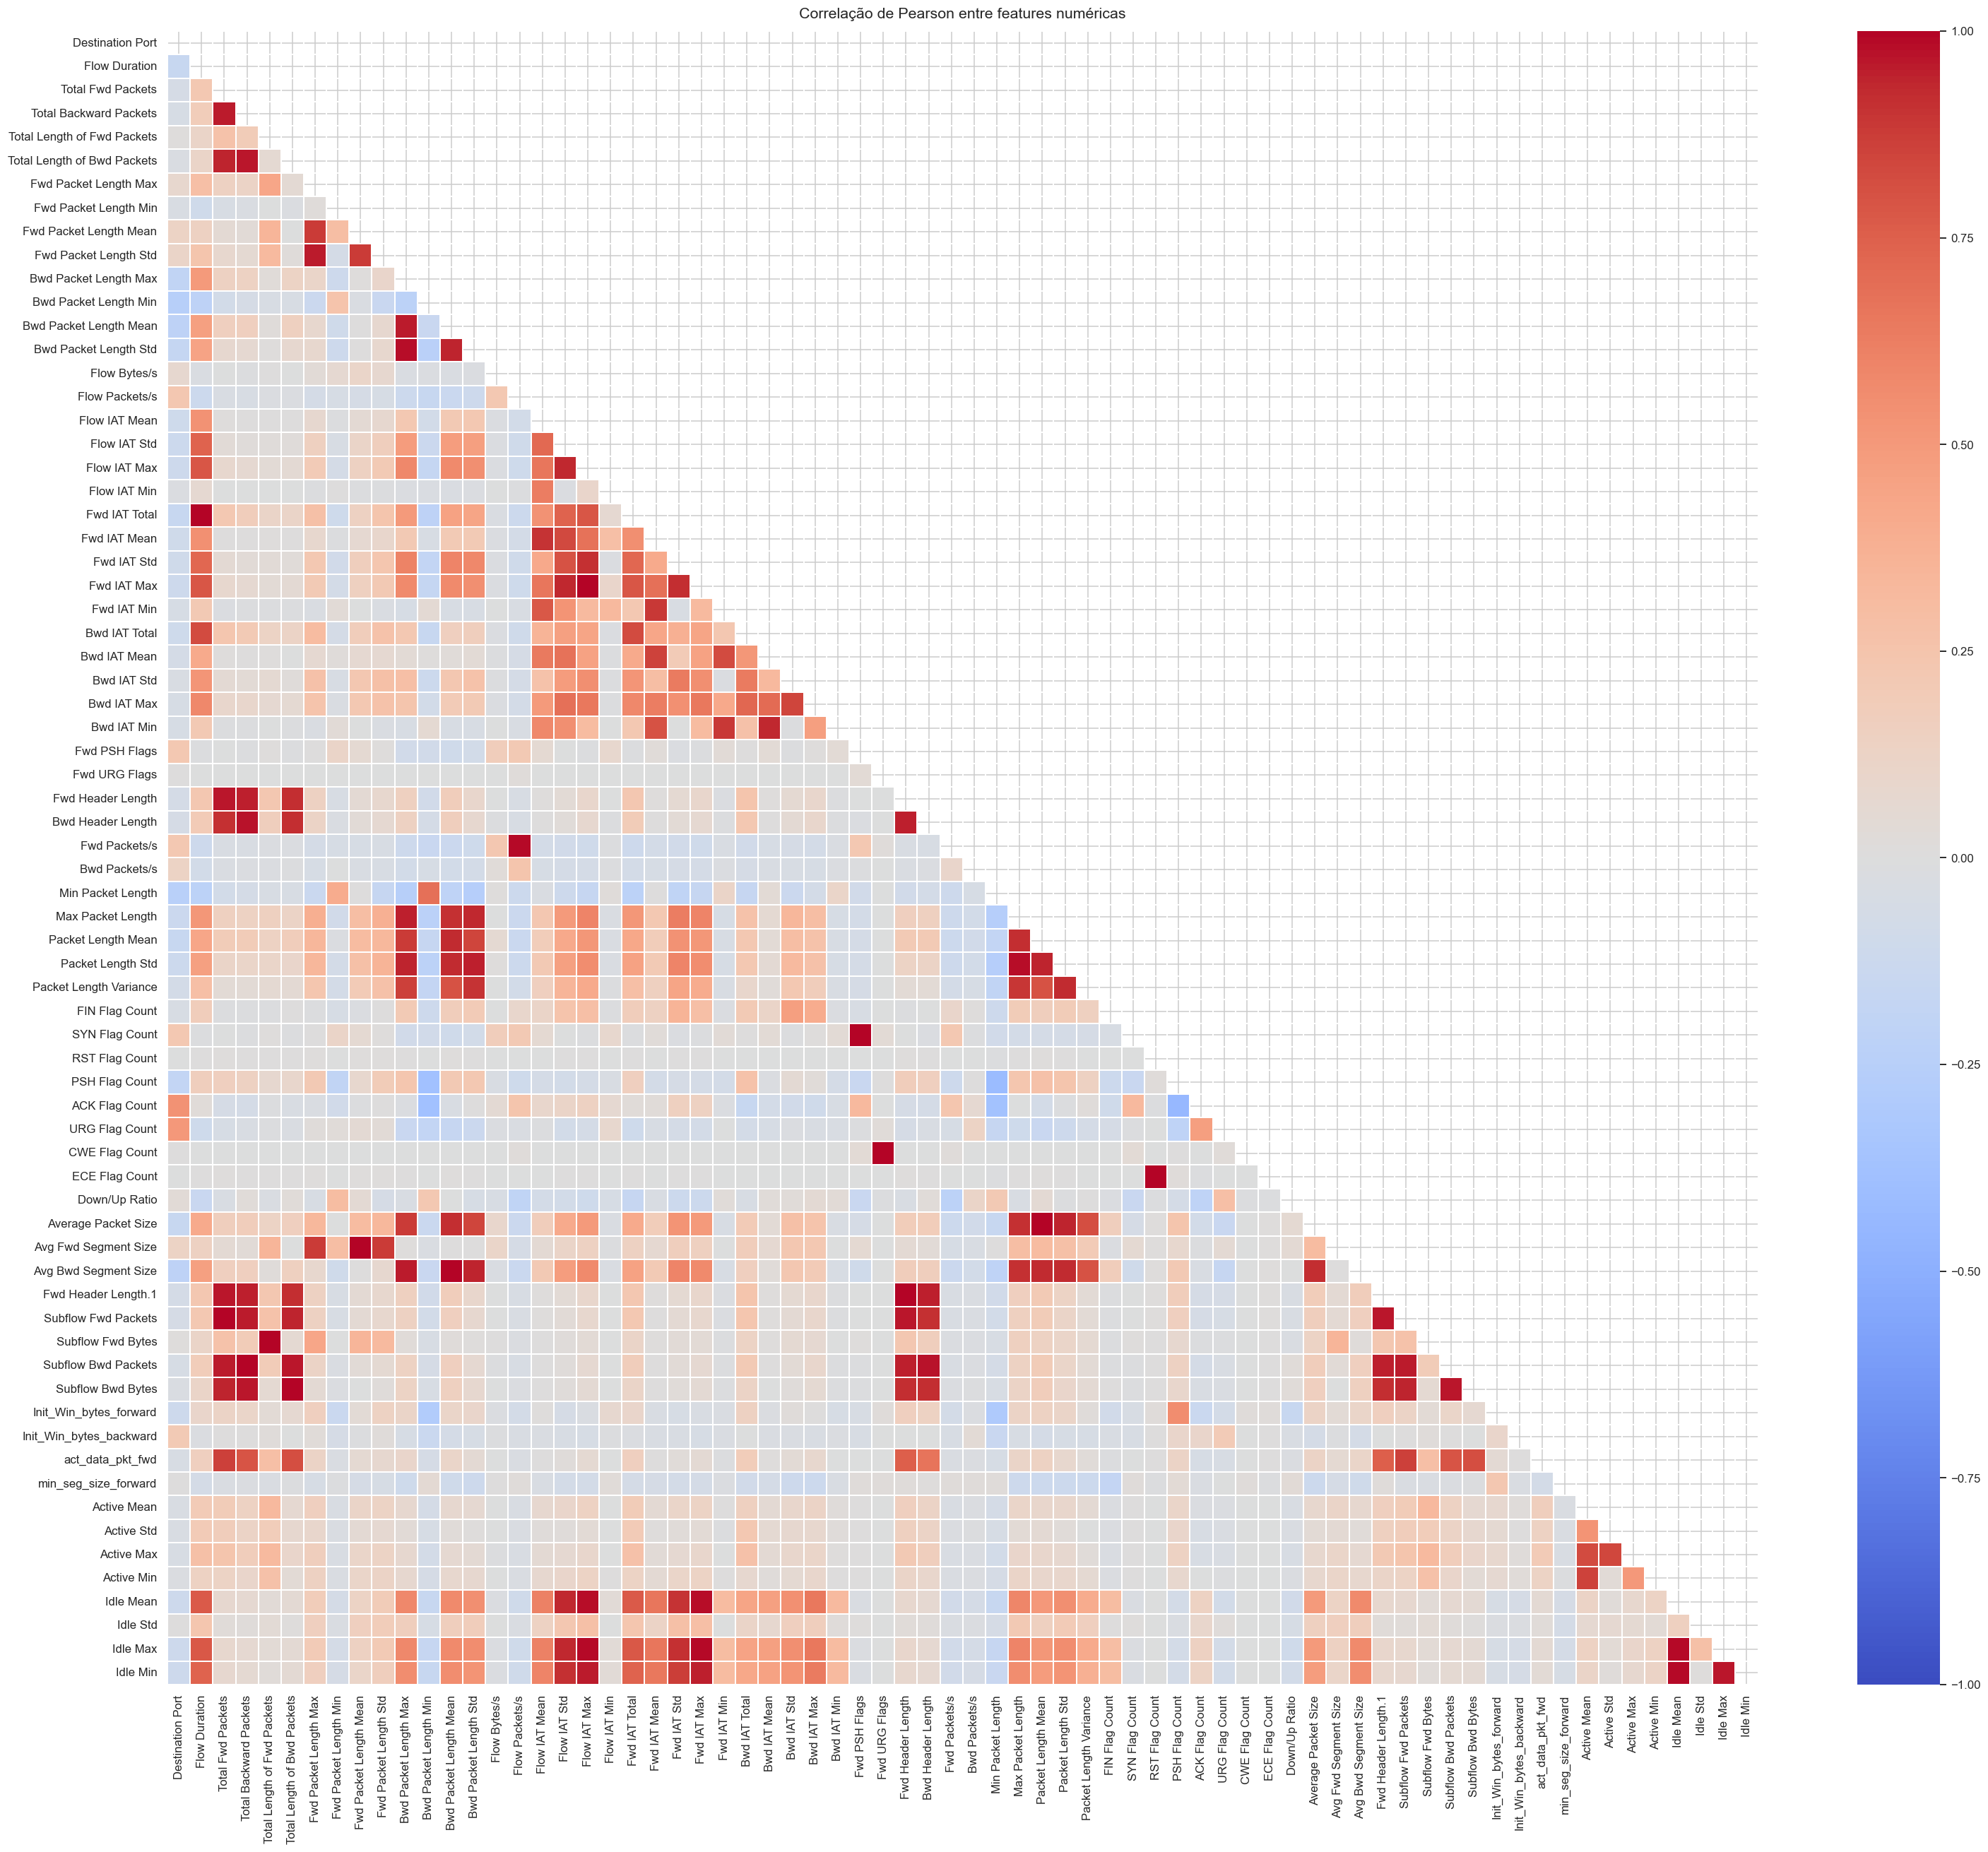

In [80]:
# Calcula correlação de Pearson entre todas as colunas numéricas
# Usa amostra de 50k linhas para ser rápido (correlação não muda muito com mais dados)
num_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
sample = raw[num_cols].sample(n=50_000, random_state=42)

corr = sample.corr()

# Heatmap — tamanho grande para 65+ colunas ficarem legíveis
fig, ax = plt.subplots(figsize=(28, 24))
mask = np.triu(np.ones_like(corr, dtype=bool))   # esconde triângulo superior (redundante)
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax
)
ax.set_title("Correlação de Pearson entre features numéricas", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [81]:
# Lista os pares de colunas com correlação alta (|r| >= 0.95)
# Útil para decidir quais remover sem precisar olhar o heatmap pixel a pixel
THRESHOLD = 0.95

upper = corr.where(mask == False)  # triângulo inferior sem diagonal
high_corr_pairs = (
    upper.abs()
    .stack()
    .reset_index()
    .rename(columns={"level_0": "col_A", "level_1": "col_B", 0: "correlação"})
    .query("col_A != col_B and correlação >= @THRESHOLD")
    .sort_values("correlação", ascending=False)
    .reset_index(drop=True)
)

print(f"Pares com |correlação| ≥ {THRESHOLD}: {len(high_corr_pairs)}\n")
print(high_corr_pairs.to_string(index=False))

Pares com |correlação| ≥ 0.95: 45

                      col_A                       col_B  correlação
             ECE Flag Count              RST Flag Count      1.0000
             SYN Flag Count               Fwd PSH Flags      1.0000
          Subflow Fwd Bytes Total Length of Fwd Packets      1.0000
        Subflow Fwd Packets           Total Fwd Packets      1.0000
        Fwd Header Length.1           Fwd Header Length      1.0000
       Avg Bwd Segment Size      Bwd Packet Length Mean      1.0000
       Avg Fwd Segment Size      Fwd Packet Length Mean      1.0000
             CWE Flag Count               Fwd URG Flags      1.0000
        Subflow Bwd Packets      Total Backward Packets      1.0000
          Subflow Bwd Bytes Total Length of Bwd Packets      1.0000
              Fwd IAT Total               Flow Duration      0.9985
                Fwd IAT Max                Flow IAT Max      0.9979
        Average Packet Size          Packet Length Mean      0.9978
             

In [82]:
# Para cada par de alta correlação, marca a segunda coluna como candidata a remoção
# (mantém col_A, remove col_B — estratégia greedy)
colunas_para_remover = set()
for _, row in high_corr_pairs.iterrows():
    if row["col_A"] not in colunas_para_remover:
        colunas_para_remover.add(row["col_B"])

print(f"Colunas candidatas a remoção por alta correlação (|r| ≥ {THRESHOLD}):")
print(f"Total: {len(colunas_para_remover)} de {len(num_cols)} colunas numéricas\n")
for c in sorted(colunas_para_remover):
    print(f"  - {c}")

Colunas candidatas a remoção por alta correlação (|r| ≥ 0.95):
Total: 23 de 70 colunas numéricas

  - Bwd Header Length
  - Bwd Packet Length Max
  - Bwd Packet Length Mean
  - Flow Duration
  - Flow IAT Max
  - Flow Packets/s
  - Fwd Header Length
  - Fwd Header Length.1
  - Fwd IAT Max
  - Fwd PSH Flags
  - Fwd Packet Length Max
  - Fwd Packet Length Mean
  - Fwd URG Flags
  - Idle Max
  - Idle Mean
  - Max Packet Length
  - Packet Length Mean
  - RST Flag Count
  - Subflow Bwd Packets
  - Total Backward Packets
  - Total Fwd Packets
  - Total Length of Bwd Packets
  - Total Length of Fwd Packets


In [83]:
# Remover colunas redundantes por alta correlação
cols_drop = [c for c in colunas_para_remover if c in raw.columns]

raw.drop(columns=cols_drop, inplace=True)

print(f"Removidas {len(cols_drop)} colunas redundantes (|r| ≥ {THRESHOLD}).")
print(f"Dataset agora: {raw.shape[0]:,} linhas × {raw.shape[1]} colunas")

Removidas 23 colunas redundantes (|r| ≥ 0.95).
Dataset agora: 2,824,951 linhas × 50 colunas


In [84]:
raw.to_parquet("../archive/raw_limpo.parquet", index=False)
print("Parquet salvo em ../archive/raw_limpo.parquet")


Parquet salvo em ../archive/raw_limpo.parquet


# EDA Aprofundada — Análise Exploratória dos Dados

Após a limpeza, analisamos a distribuição das classes, os tipos de ataque, o volume por dia e o comportamento das principais *features* — incluindo detecção de outliers via IQR.


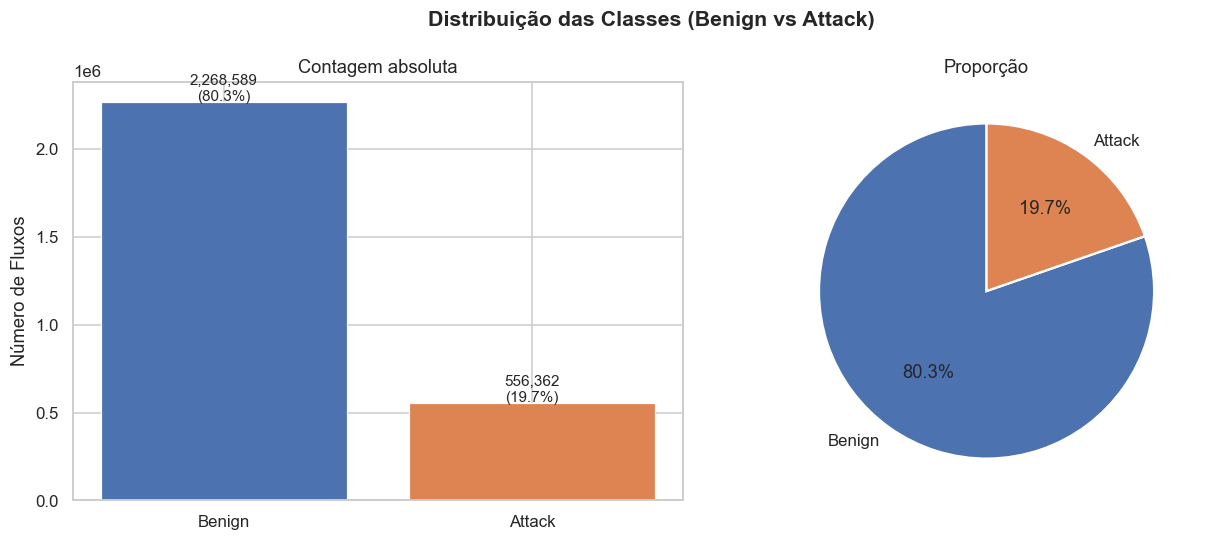

Attack
Benign    2268589
Attack     556362


In [85]:
## ── 1. Distribuição Binária das Classes ─────────────────────────────────────
contagem = raw["Attack"].value_counts()
pct_classes = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribuição das Classes (Benign vs Attack)", fontsize=14, fontweight="bold")

# Barras
cores = ["#4C72B0", "#DD8452"]
axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor="white", linewidth=0.8)
axes[0].set_ylabel("Número de Fluxos")
axes[0].set_title("Contagem absoluta")
for i, (v, p) in enumerate(zip(contagem.values, pct_classes.values)):
    axes[0].text(i, v + 5000, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=10)

# Pizza
axes[1].pie(
    contagem.values, labels=contagem.index, autopct="%1.1f%%",
    colors=cores, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[1].set_title("Proporção")

plt.tight_layout()
plt.savefig("../archive/eda_01_distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print(contagem.to_string())


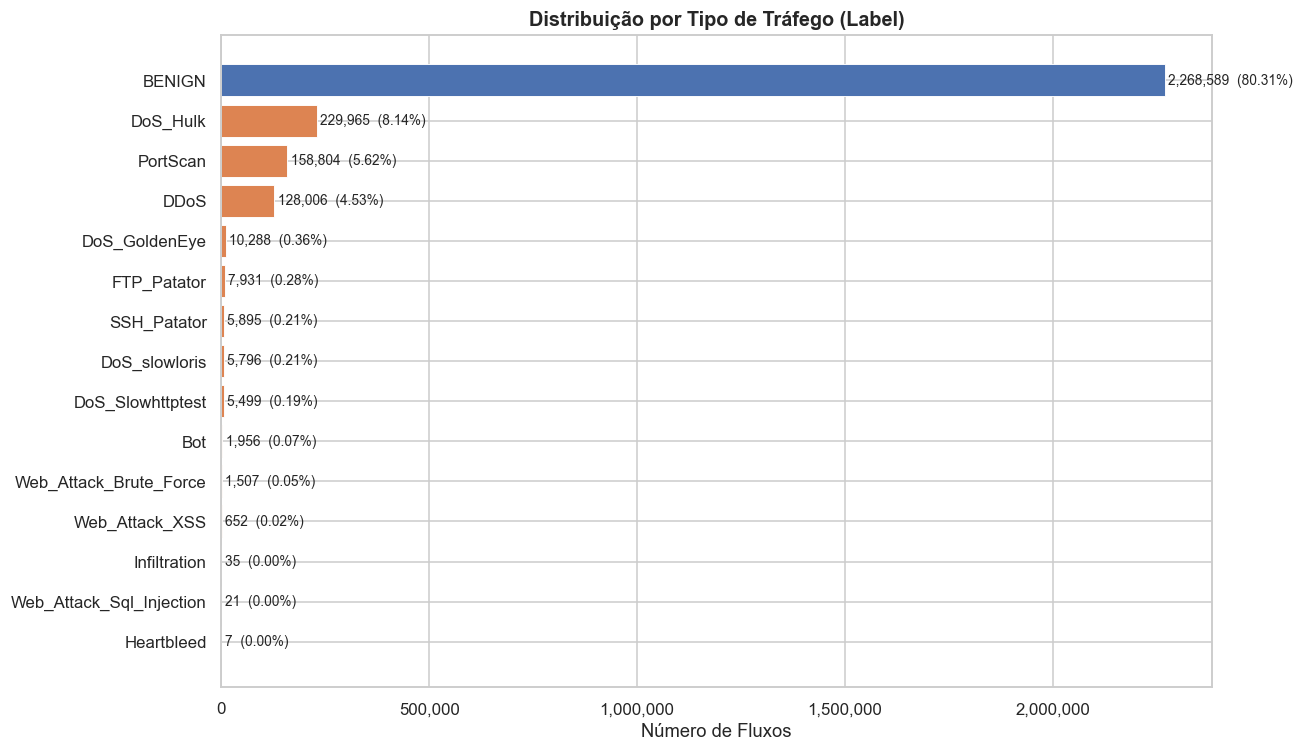

In [86]:
## ── 2. Tipos de Ataque (Label detalhado) ─────────────────────────────────────
import matplotlib.ticker as mticker

label_counts = raw["Label"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(label_counts.index, label_counts.values,
               color=["#4C72B0" if "BENIGN" in v else "#DD8452" for v in label_counts.index],
               edgecolor="white", linewidth=0.6)

ax.set_xlabel("Número de Fluxos")
ax.set_title("Distribuição por Tipo de Tráfego (Label)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, v in zip(bars, label_counts.values):
    pct = v / len(raw) * 100
    ax.text(bar.get_width() + len(raw) * 0.003, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({pct:.2f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../archive/eda_02_tipos_ataque.png", dpi=150, bbox_inches="tight")
plt.show()


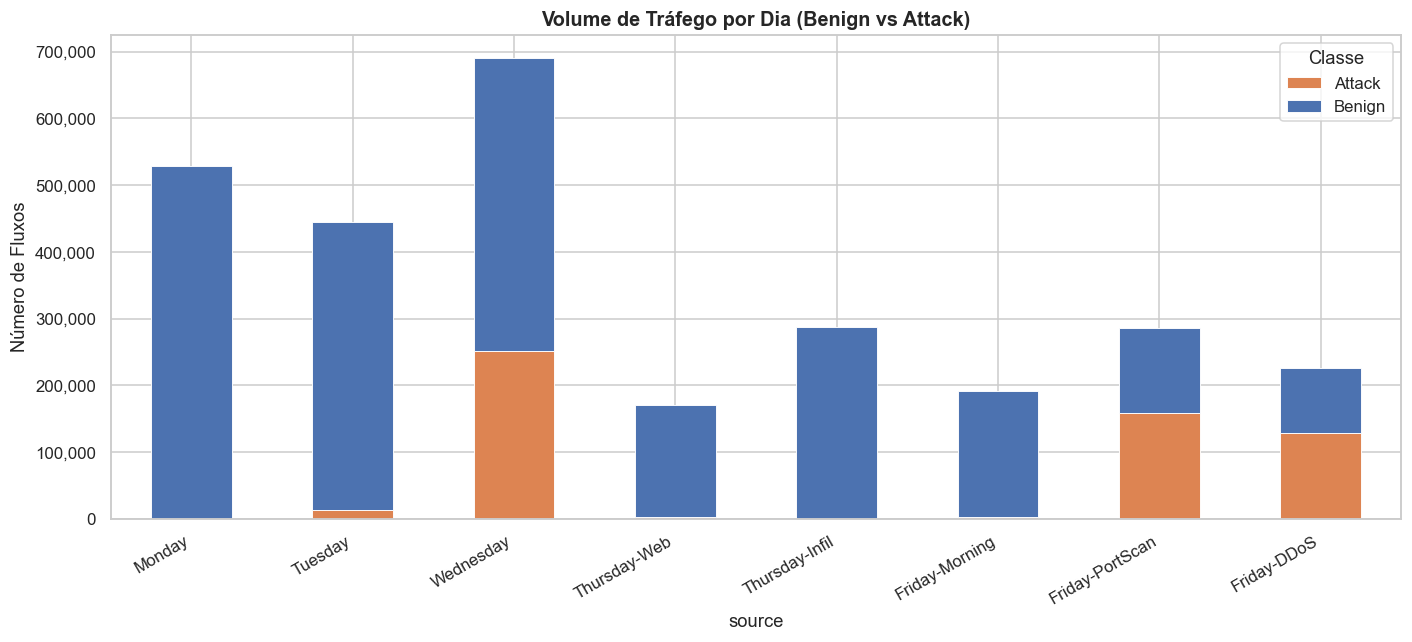

In [87]:
## ── 3. Volume de Tráfego por Dia / Arquivo ───────────────────────────────────
source_counts = raw.groupby(["source", "Attack"]).size().unstack(fill_value=0)

# Reordenar por dia da semana
ordem = ["Monday", "Tuesday", "Wednesday",
         "Thursday-Web", "Thursday-Infil",
         "Friday-Morning", "Friday-PortScan", "Friday-DDoS"]
source_counts = source_counts.reindex([d for d in ordem if d in source_counts.index])

fig, ax = plt.subplots(figsize=(13, 6))
source_counts.plot(
    kind="bar", stacked=True, ax=ax,
    color={"Benign": "#4C72B0", "Attack": "#DD8452"},
    edgecolor="white", linewidth=0.6
)
ax.set_xticklabels(source_counts.index, rotation=30, ha="right")
ax.set_ylabel("Número de Fluxos")
ax.set_title("Volume de Tráfego por Dia (Benign vs Attack)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Classe")

plt.tight_layout()
plt.savefig("../archive/eda_03_volume_por_dia.png", dpi=150, bbox_inches="tight")
plt.show()


In [88]:
## ── 4. Análise de Outliers — Tabela IQR ─────────────────────────────────────
# Para cada feature numérica calcula quantos pontos estão além de 1.5×IQR
feat_num = [c for c in raw.select_dtypes(include=np.number).columns
            if c not in ["Attack"]]

outlier_stats = []
for col in feat_num:
    s = raw[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        continue
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((s < low) | (s > high)).sum()
    outlier_stats.append({
        "Feature": col,
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "Limite Inferior": low, "Limite Superior": high,
        "Outliers (n)": n_out,
        "Outliers (%)": round(n_out / len(s) * 100, 2)
    })

df_out = (pd.DataFrame(outlier_stats)
            .sort_values("Outliers (%)", ascending=False)
            .reset_index(drop=True))

print(f"Features com maior proporção de outliers (IQR 1.5×):\n")
print(df_out[["Feature", "Outliers (n)", "Outliers (%)"]].head(20).to_string(index=False))


Features com maior proporção de outliers (IQR 1.5×):

               Feature  Outliers (n)  Outliers (%)
          Fwd IAT Mean        670682       23.7400
         Fwd IAT Total        664470       23.5200
 Fwd Packet Length Std        662063       23.4400
           Fwd IAT Std        659722       23.3500
Packet Length Variance        652698       23.1000
 Bwd Packet Length Std        652270       23.0900
      Destination Port        625757       22.1500
     Subflow Bwd Bytes        617061       21.8400
          Flow IAT Std        599193       21.2100
           Bwd IAT Std        597984       21.1700
         Flow IAT Mean        572338       20.2600
           Bwd IAT Max        567207       20.0800
         Bwd IAT Total        564650       19.9900
          Bwd IAT Mean        562860       19.9200
     Packet Length Std        562018       19.8900
           Fwd IAT Min        534653       18.9300
          Flow Bytes/s        530582       18.7800
          Flow IAT Min      

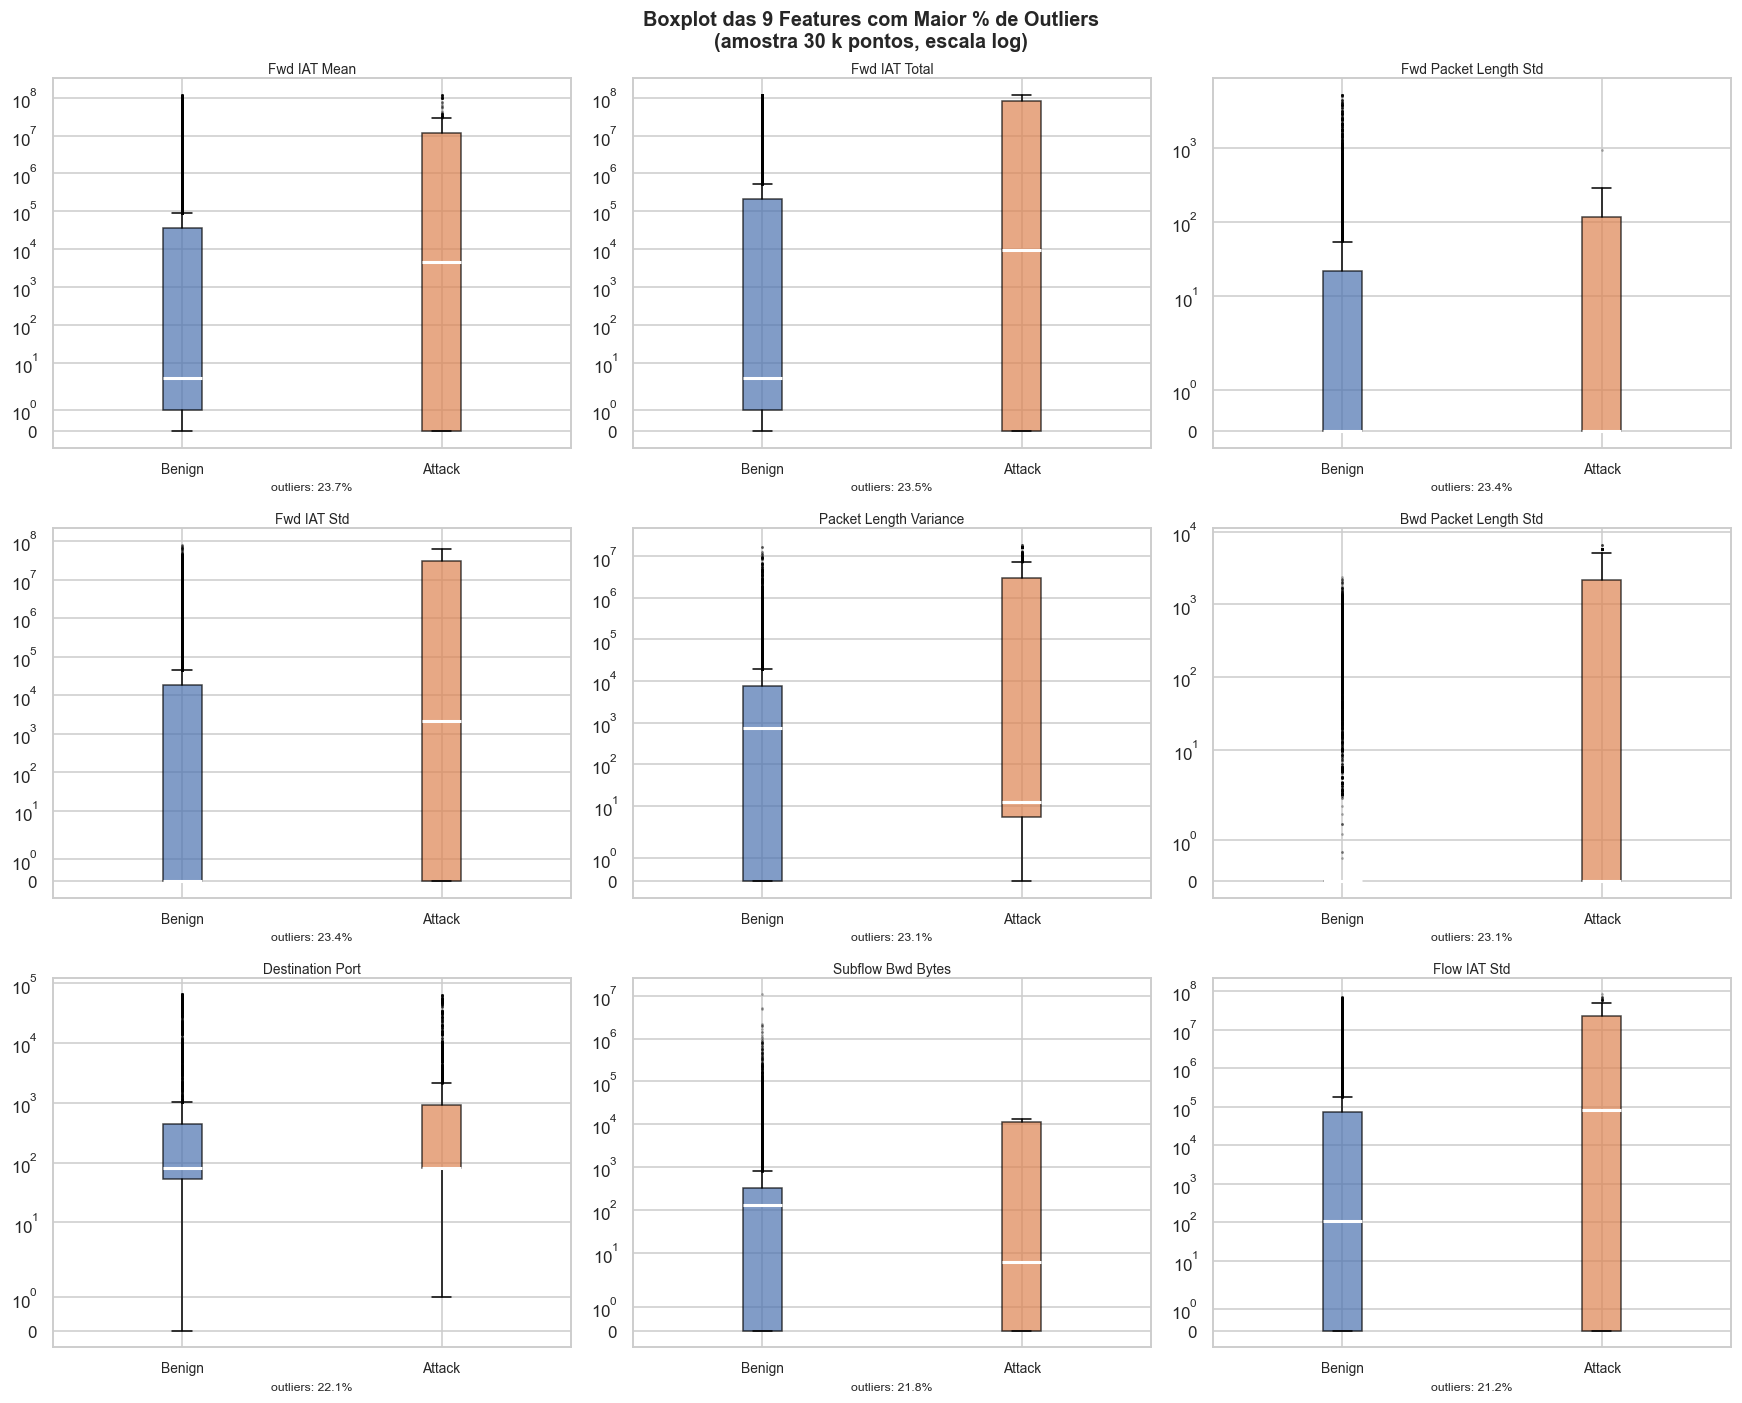

In [89]:
## ── 5. Boxplots das Features com Mais Outliers (por Classe) ─────────────────
# Seleciona as 9 features com mais outliers (%)
top9 = df_out.head(9)["Feature"].tolist()

# Amostra para não sobrecarregar o plot (2.8M → 30k)
sample = raw[top9 + ["Attack"]].sample(n=30_000, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Boxplot das 9 Features com Maior % de Outliers\n(amostra 30 k pontos, escala log)",
             fontsize=13, fontweight="bold")

cores_box = {"Benign": "#4C72B0", "Attack": "#DD8452"}

for ax, col in zip(axes.flatten(), top9):
    data_by_class = [
        sample.loc[sample["Attack"] == cls, col].dropna().values
        for cls in ["Benign", "Attack"]
    ]
    bp = ax.boxplot(
        data_by_class, labels=["Benign", "Attack"],
        patch_artist=True, notch=False,
        medianprops=dict(color="white", linewidth=2),
        flierprops=dict(marker=".", markersize=1.5, alpha=0.3)
    )
    for patch, color in zip(bp["boxes"], cores_box.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    try:
        vals = sample[col].dropna()
        if vals[vals > 0].min() > 0 and vals.max() / vals[vals > 0].min() > 1000:
            ax.set_yscale("symlog")
    except Exception:
        pass

    ax.set_title(col, fontsize=9, pad=3)
    ax.tick_params(axis="x", labelsize=9)
    pct = df_out.loc[df_out["Feature"] == col, "Outliers (%)"].values[0]
    ax.set_xlabel(f"outliers: {pct:.1f}%", fontsize=8)

plt.tight_layout()
plt.savefig("../archive/eda_04_boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()


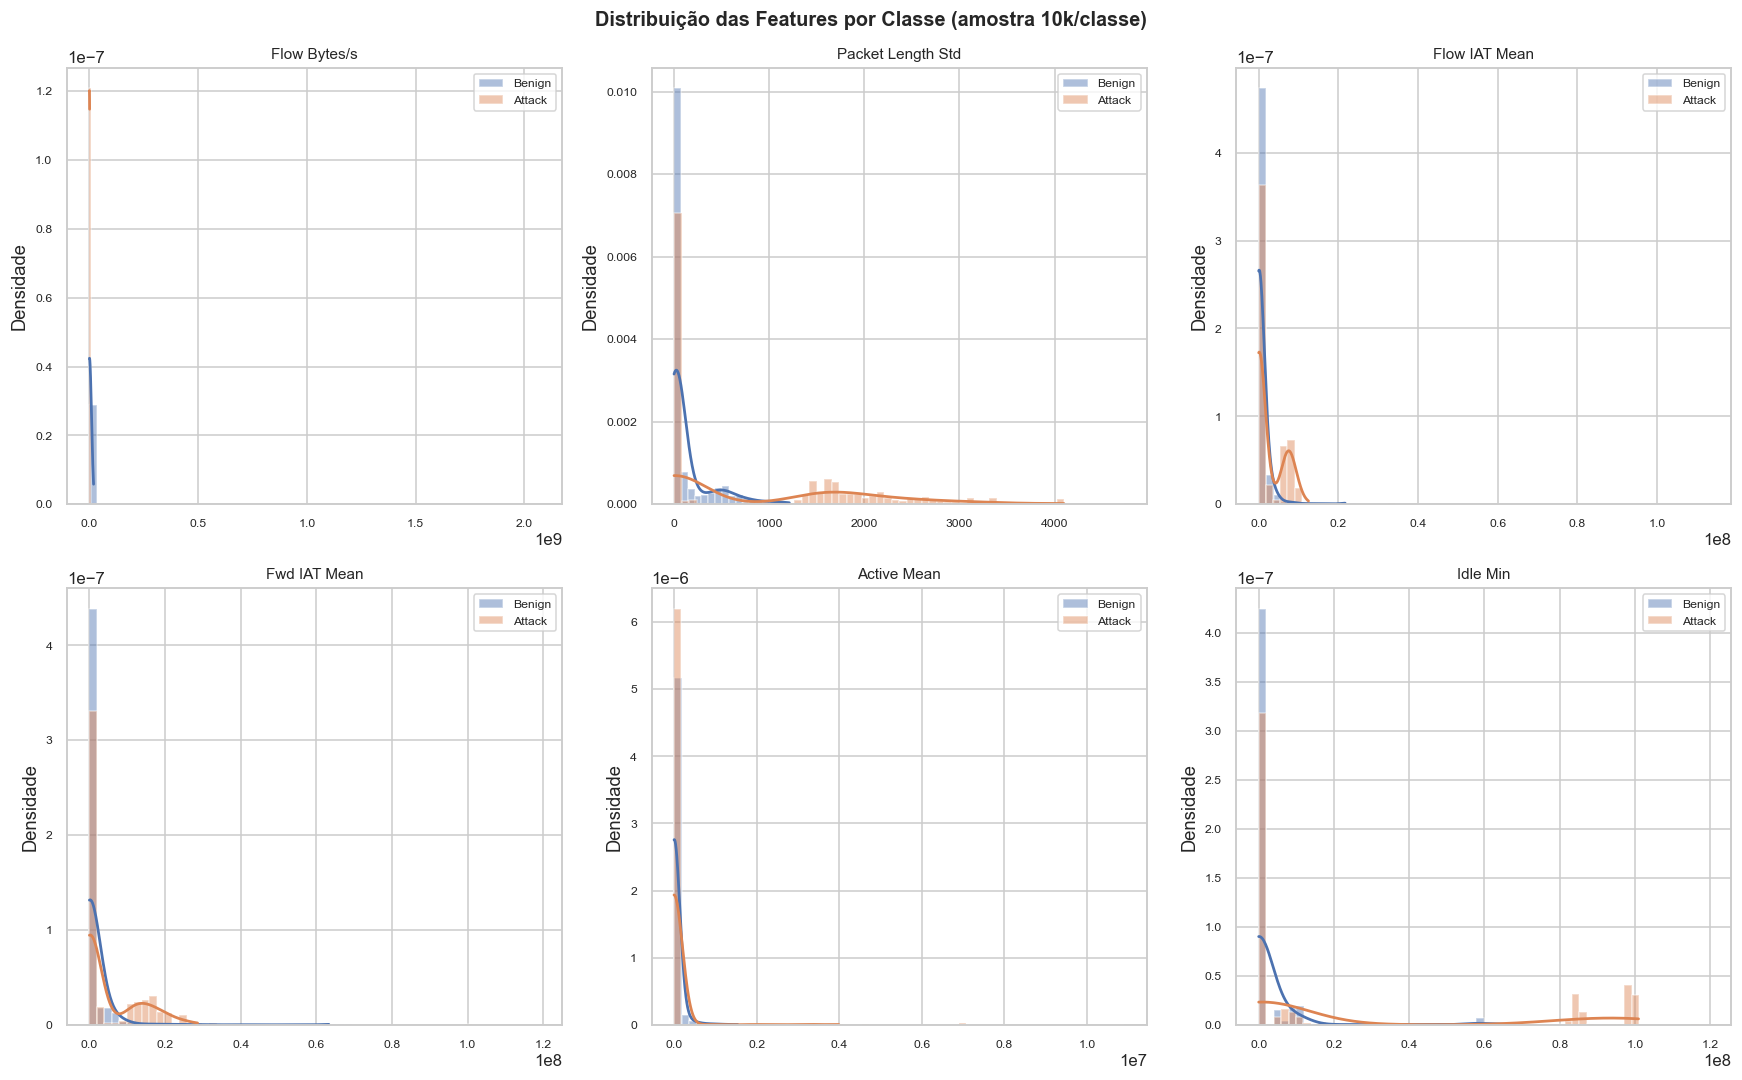

In [90]:
## ── 6. Distribuição de Features Chave por Classe (KDE + Histograma) ─────────
from scipy.stats import gaussian_kde

features_plot = [
    "Flow Bytes/s",
    "Packet Length Std",
    "Flow IAT Mean",
    "Fwd IAT Mean",
    "Active Mean",
    "Idle Min",
]

# Amostra estratificada (10k por classe para visualização clara)
s_benign = raw[raw["Attack"] == "Benign"].sample(n=10_000, random_state=42)
s_attack = raw[raw["Attack"] == "Attack"].sample(n=10_000, random_state=42)
sample_kde = pd.concat([s_benign, s_attack], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribuição das Features por Classe (amostra 10k/classe)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes.flatten(), features_plot):
    for cls, cor in [("Benign", "#4C72B0"), ("Attack", "#DD8452")]:
        vals = sample_kde.loc[sample_kde["Attack"] == cls, col].dropna()
        ax.hist(vals, bins=60, color=cor, alpha=0.45, label=cls, density=True)
        try:
            kde = gaussian_kde(vals, bw_method=0.3)
            x = np.linspace(vals.quantile(0.01), vals.quantile(0.99), 300)
            ax.plot(x, kde(x), color=cor, linewidth=1.8)
        except Exception:
            pass

    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("../archive/eda_05_histogramas_kde.png", dpi=150, bbox_inches="tight")
plt.show()


In [91]:
## ── 7. Estatísticas Descritivas por Classe ──────────────────────────────────
feat_desc = [
    "Flow Bytes/s", "Packet Length Std", "Flow IAT Mean",
    "Fwd IAT Mean", "Active Mean", "Idle Min",
    "Init_Win_bytes_forward", "Init_Win_bytes_backward",
]

stats_list = []
for cls in ["Benign", "Attack"]:
    subset = raw[raw["Attack"] == cls][feat_desc]
    s = subset.describe().T[["mean", "std", "50%", "min", "max"]]
    s.columns = ["Média", "Desvio Padrão", "Mediana", "Mín", "Máx"]
    s.index.name = "Feature"
    s.insert(0, "Classe", cls)
    stats_list.append(s.reset_index())

df_stats = pd.concat(stats_list).set_index(["Classe", "Feature"])
print("Estatísticas Descritivas por Classe:\n")
print(df_stats.to_string(float_format=lambda x: f"{x:,.2f}"))


Estatísticas Descritivas por Classe:

                                       Média  Desvio Padrão   Mediana   Mín              Máx
Classe Feature                                                                              
Benign Flow Bytes/s             1,781,884.59  28,159,373.51  5,148.93  0.00 2,071,000,000.00
       Packet Length Std              147.15         305.56     27.39  0.00         4,731.52
       Flow IAT Mean              910,012.09   4,121,281.57 10,579.67  0.33   120,000,000.00
       Fwd IAT Mean             1,902,760.00   9,298,208.63      4.00  0.00   120,000,000.00
       Active Mean                 75,097.48     615,014.41      0.00  0.00   110,000,000.00
       Idle Min                 3,505,098.95  13,186,038.51      0.00  0.00   120,000,000.00
       Init_Win_bytes_forward       6,875.65      14,908.48    118.00 -1.00        65,535.00
       Init_Win_bytes_backward      2,402.15       9,318.22     -1.00 -1.00        65,535.00
Attack Flow Bytes/s             

# Pós EDA

## Preparaçao para tabela de features

In [13]:
# ─── Verifica Python e garante dependências (idempotente) ─────────────
import sys, subprocess
from pathlib import Path as _Path
if sys.version_info < (3, 10):
    raise RuntimeError(f"Python {sys.version_info.major}.{sys.version_info.minor} é antigo demais — precisa 3.10+. Veja a célula de Setup no topo do notebook para instruções.")
_candidatos = [_Path("../../requirements.txt"), _Path("../requirements.txt"), _Path("requirements.txt")]
_req = next((p for p in _candidatos if p.exists()), None)
if _req:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(_req)])
    except subprocess.CalledProcessError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(_req)])

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
import urllib.request

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 110

sns.set_theme(style="whitegrid", palette="muted")
PARQUET = Path("../archive/raw_limpo.parquet")

# ─── Auto-download do dataset pré-processado (caso não exista localmente) ───
RELEASE_URL = "https://github.com/vinigm/projeto-ddos/releases/download/v1.0/raw_limpo.parquet"
if not PARQUET.exists():
    print(f"📥 Baixando dataset pré-processado (~224 MB) do release v1.0...")
    PARQUET.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(RELEASE_URL, PARQUET)
    print(f"✅ Download concluído: {PARQUET}")
else:
    print(f"✓ Dataset já presente: {PARQUET}")

# ─── Cache de artefatos (modelos, scores de CV, SHAP, hyperparams) ─────────
ARTIFACTS_DIR = Path("../../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RECOMPUTE = False   # True = ignora cache e recomputa tudo (~6h)
print(f"📦 Cache em: {ARTIFACTS_DIR.resolve()}")
print(f"   RECOMPUTE = {RECOMPUTE}")


📥 Baixando dataset pré-processado (~224 MB) do release v1.0...
✅ Download concluído: ../archive/raw_limpo.parquet
📦 Cache em: /workspace/artifacts
   RECOMPUTE = False


In [14]:
df = pd.read_parquet(PARQUET)

print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())
print(f"\nNulos por coluna:")
nulos = df.isna().sum()
print(nulos[nulos > 0] if nulos.any() else "  Nenhum valor nulo.")

Shape: 2,824,951 linhas × 50 colunas

Tipos de dados:
int64      28
float64    19
str         3
Name: count, dtype: int64

Nulos por coluna:
  Nenhum valor nulo.


In [15]:
df.head(3)

,Destination Port,Fwd Packet Length Min,Fwd Packet Length Std,Bwd Packet Length Min,Bwd Packet Length Std,Flow Bytes/s,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Std,Idle Min,Label,source,Attack
0,49188,6,0.0000,0,0.0000,3000000.0000,4.0000,0.0000,4,4,4.0000,0.0000,4,0,0.0000,0.0000,0,0,500000.0000,0.0000,6,0.0000,0.0000,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,2,12,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0,BENIGN,Monday,Benign
1,49188,6,0.0000,0,0.0000,12000000.0000,1.0000,0.0000,1,1,1.0000,0.0000,1,0,0.0000,0.0000,0,0,2000000.0000,0.0000,6,0.0000,0.0000,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,2,12,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0,BENIGN,Monday,Benign
2,49188,6,0.0000,0,0.0000,12000000.0000,1.0000,0.0000,1,1,1.0000,0.0000,1,0,0.0000,0.0000,0,0,2000000.0000,0.0000,6,0.0000,0.0000,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,2,12,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0,BENIGN,Monday,Benign


In [95]:
pd.DataFrame({"coluna": df.columns, "dtype": df.dtypes.values})

,coluna,dtype
0,Destination Port,int64
1,Fwd Packet Length Min,int64
2,Fwd Packet Length Std,float64
3,Bwd Packet Length Min,int64
4,Bwd Packet Length Std,float64
5,Flow Bytes/s,float64
6,Flow IAT Mean,float64
7,Flow IAT Std,float64
8,Flow IAT Min,int64
9,Fwd IAT Total,int64


In [16]:
# Verificar distribuição do target (Attack) e do Label detalhado
print("=== TARGET BINÁRIO (Attack) ===")
print(df["Attack"].value_counts())
print(f"\nBalanceamento: {df['Attack'].value_counts(normalize=True).mul(100).round(2).to_string()}")

print("\n=== LABELS DETALHADOS ===")
print(df["Label"].value_counts().to_string())

print("\n=== COLUNAS NÃO NUMÉRICAS ===")
print(df.select_dtypes(include="object").columns.tolist())

=== TARGET BINÁRIO (Attack) ===
Attack
Benign    2268589
Attack     556362
Name: count, dtype: int64

Balanceamento: Attack
Benign   80.3100
Attack   19.6900

=== LABELS DETALHADOS ===
Label
BENIGN                      2268589
DoS_Hulk                     229965
PortScan                     158804
DDoS                         128006
DoS_GoldenEye                 10288
FTP_Patator                    7931
SSH_Patator                    5895
DoS_slowloris                  5796
DoS_Slowhttptest               5499
Bot                            1956
Web_Attack_Brute_Force         1507
Web_Attack_XSS                  652
Infiltration                     35
Web_Attack_Sql_Injection         21
Heartbleed                        7

=== COLUNAS NÃO NUMÉRICAS ===
['Label', 'source', 'Attack']


## Tabela de Features Final

In [18]:
# Features: todas as colunas numéricas (excluindo metadados e target)
COLUNAS_EXCLUIR = ["Label", "source", "Attack"]

feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in COLUNAS_EXCLUIR]

X = df[feature_cols]
y = df["Attack"]

# Tabela de features com estatísticas básicas
tabela_features = pd.DataFrame({
    "feature": feature_cols,
    "dtype": X.dtypes.values,
    "min": X.min().values,
    "max": X.max().values,
    "mean": X.mean().values,
    "std": X.std().values,
    "nulos": X.isna().sum().values,
})

print(f"Features: {len(feature_cols)}  |  Amostras: {len(X):,}  |  Target: 'Attack' (Benign / Attack)")
print()
tabela_features

Features: 47  |  Amostras: 2,824,951  |  Target: 'Attack' (Benign / Attack)



,feature,dtype,min,max,mean,std,nulos
0,Destination Port,int64,0.0000,65535.0000,8066.7677,18279.5281,0
1,Fwd Packet Length Min,int64,0.0000,2325.0000,18.7474,60.3835,0
2,Fwd Packet Length Std,float64,0.0000,7125.5968,68.8792,281.1916,0
3,Bwd Packet Length Min,int64,0.0000,2896.0000,41.1289,68.8978,0
4,Bwd Packet Length Std,float64,0.0000,8194.6605,335.2227,840.1425,0
5,Flow Bytes/s,float64,0.0000,2071000000.0000,1493176.7904,25952475.2399,0
6,Flow IAT Mean,float64,0.3333,120000000.0000,1300183.9341,4511955.4911,0
7,Flow IAT Std,float64,0.0000,84800261.5664,2921871.6796,8051087.2432,0
8,Flow IAT Min,int64,0.0000,120000000.0000,162712.0731,2953295.5585,0
9,Fwd IAT Total,int64,0.0000,120000000.0000,14455408.3915,33542935.1382,0


# Holdout tradicional

## Train / Test Split

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # mantém a proporção 80/20 de Benign/Attack nos dois conjuntos
)

print(f"Train: {X_train.shape[0]:,} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} amostras ({len(X_test)/len(X)*100:.1f}%)")
print()
print("Distribuição do target no train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print("\nDistribuição do target no test:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train: 2,259,960 amostras (80.0%)
Test:  564,991 amostras (20.0%)

Distribuição do target no train:
Attack
Benign   80.3100
Attack   19.6900
Name: proportion, dtype: float64

Distribuição do target no test:
Attack
Benign   80.3100
Attack   19.6900
Name: proportion, dtype: float64


## Modelo 1 — Regressão Logística

Tempo de treino: 11.6s

=== Classification Report ===
              precision    recall  f1-score   support

      Attack       0.79      0.95      0.86    111273
      Benign       0.99      0.94      0.96    453718

    accuracy                           0.94    564991
   macro avg       0.89      0.95      0.91    564991
weighted avg       0.95      0.94      0.94    564991

ROC-AUC: 0.9816


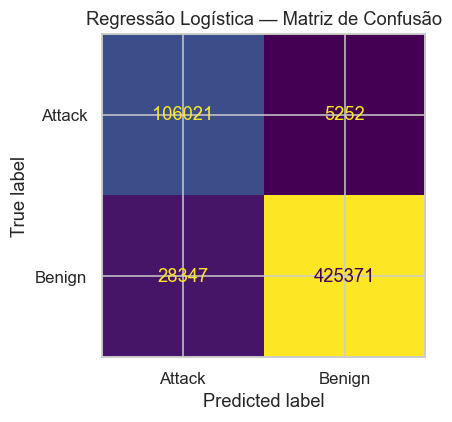

In [99]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# --- Escalonamento (rápido — sempre re-fita) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- Treino com cache ---
LR_PATH = ARTIFACTS_DIR / "lr.joblib"
if not RECOMPUTE and LR_PATH.exists():
    lr, tempo_treino = joblib.load(LR_PATH)
    print(f"✓ LR carregado do cache (tempo original: {tempo_treino:.1f}s)")
else:
    lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1)
    t0 = time.time()
    lr.fit(X_train_sc, y_train)
    tempo_treino = time.time() - t0
    joblib.dump((lr, tempo_treino), LR_PATH, compress=3)
    print(f"💾 LR salvo em {LR_PATH.name} (tempo: {tempo_treino:.1f}s)")

# --- Avaliação ---
y_pred = lr.predict(X_test_sc)
y_prob = lr.predict_proba(X_test_sc)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# --- Matriz de confusão ---
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Regressão Logística — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Modelo 2 — Random Forest

Tempo de treino: 49.3s

=== Classification Report ===
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00    111273
      Benign       1.00      1.00      1.00    453718

    accuracy                           1.00    564991
   macro avg       1.00      1.00      1.00    564991
weighted avg       1.00      1.00      1.00    564991

ROC-AUC: 0.9998


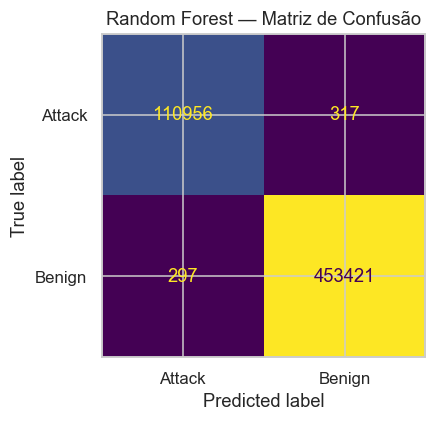

In [100]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest não precisa de escalonamento
# --- Treino com cache ---
RF_PATH = ARTIFACTS_DIR / "rf_baseline.joblib"
if not RECOMPUTE and RF_PATH.exists():
    rf, tempo_treino_rf = joblib.load(RF_PATH)
    print(f"✓ RF baseline carregado do cache (tempo original: {tempo_treino_rf:.1f}s)")
else:
    rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
    t0 = time.time()
    rf.fit(X_train, y_train)
    tempo_treino_rf = time.time() - t0
    joblib.dump((rf, tempo_treino_rf), RF_PATH, compress=3)
    print(f"💾 RF baseline salvo em {RF_PATH.name} (tempo: {tempo_treino_rf:.1f}s)")

# --- Avaliação ---
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, colorbar=False)
ax.set_title("Random Forest — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Modelo 3 — Árvore de Decisão

Tempo de treino: 31.5s

=== Classification Report ===
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00    111273
      Benign       1.00      1.00      1.00    453718

    accuracy                           1.00    564991
   macro avg       1.00      1.00      1.00    564991
weighted avg       1.00      1.00      1.00    564991

ROC-AUC: 0.9982


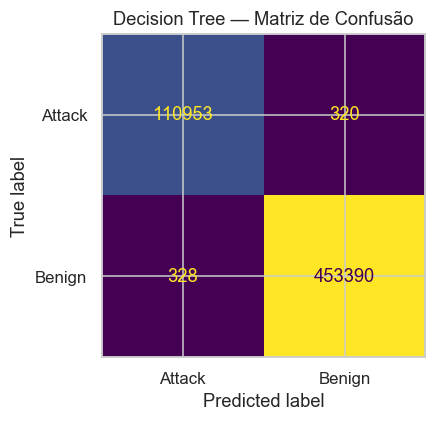

In [101]:
from sklearn.tree import DecisionTreeClassifier

# --- Treino com cache ---
DT_PATH = ARTIFACTS_DIR / "dt.joblib"
if not RECOMPUTE and DT_PATH.exists():
    dt, tempo_treino_dt = joblib.load(DT_PATH)
    print(f"✓ Decision Tree carregado do cache (tempo original: {tempo_treino_dt:.1f}s)")
else:
    dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
    t0 = time.time()
    dt.fit(X_train, y_train)
    tempo_treino_dt = time.time() - t0
    joblib.dump((dt, tempo_treino_dt), DT_PATH, compress=3)
    print(f"💾 Decision Tree salvo em {DT_PATH.name} (tempo: {tempo_treino_dt:.1f}s)")

y_pred_dt = dt.predict(X_test)
y_prob_dt  = dt.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=ax, colorbar=False)
ax.set_title("Decision Tree — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Modelo 4 — Hist Gradient Boosting

Tempo de treino: 12.7s

=== Classification Report ===
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00    111273
      Benign       1.00      1.00      1.00    453718

    accuracy                           1.00    564991
   macro avg       1.00      1.00      1.00    564991
weighted avg       1.00      1.00      1.00    564991

ROC-AUC: 0.9999


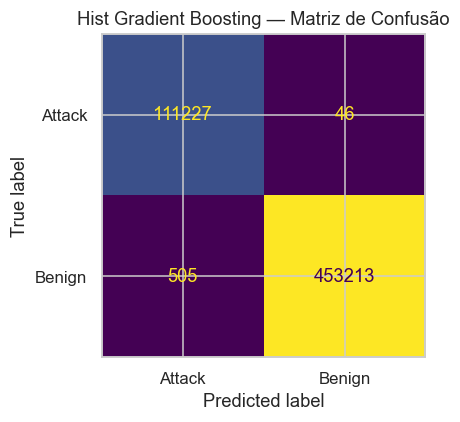

In [102]:
from sklearn.ensemble import HistGradientBoostingClassifier

# --- Treino com cache ---
HGB_PATH = ARTIFACTS_DIR / "hgb_baseline.joblib"
if not RECOMPUTE and HGB_PATH.exists():
    hgb, tempo_treino_hgb = joblib.load(HGB_PATH)
    print(f"✓ HGB baseline carregado do cache (tempo original: {tempo_treino_hgb:.1f}s)")
else:
    hgb = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
    t0 = time.time()
    hgb.fit(X_train, y_train)
    tempo_treino_hgb = time.time() - t0
    joblib.dump((hgb, tempo_treino_hgb), HGB_PATH, compress=3)
    print(f"💾 HGB baseline salvo em {HGB_PATH.name} (tempo: {tempo_treino_hgb:.1f}s)")

y_pred_hgb = hgb.predict(X_test)
y_prob_hgb  = hgb.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_hgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_hgb):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_hgb, ax=ax, colorbar=False)
ax.set_title("Hist Gradient Boosting — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Modelo 5 — Naive Bayes

Tempo de treino: 2.6s

=== Classification Report ===
              precision    recall  f1-score   support

      Attack       0.75      0.46      0.57    111273
      Benign       0.88      0.96      0.92    453718

    accuracy                           0.86    564991
   macro avg       0.82      0.71      0.75    564991
weighted avg       0.85      0.86      0.85    564991

ROC-AUC: 0.7268


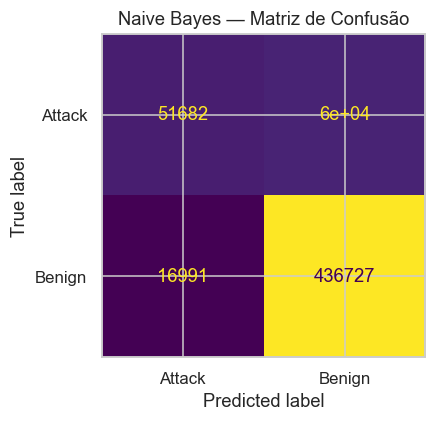

In [103]:
from sklearn.naive_bayes import GaussianNB

# --- Treino com cache ---
NB_PATH = ARTIFACTS_DIR / "nb.joblib"
if not RECOMPUTE and NB_PATH.exists():
    nb, tempo_treino_nb = joblib.load(NB_PATH)
    print(f"✓ Naive Bayes carregado do cache (tempo original: {tempo_treino_nb:.1f}s)")
else:
    nb = GaussianNB()
    t0 = time.time()
    nb.fit(X_train, y_train)
    tempo_treino_nb = time.time() - t0
    joblib.dump((nb, tempo_treino_nb), NB_PATH, compress=3)
    print(f"💾 Naive Bayes salvo em {NB_PATH.name} (tempo: {tempo_treino_nb:.1f}s)")

y_pred_nb = nb.predict(X_test)
y_prob_nb  = nb.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_nb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nb):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=ax, colorbar=False)
ax.set_title("Naive Bayes — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Comparativo Final — Spot-checking

=== SPOT-CHECKING — Comparativo Final ===

                Modelo  Accuracy  Precision  Recall  F1-Attack  ROC-AUC  Tempo (s)
Hist Gradient Boosting    0.9990     0.9955  0.9996     0.9975   0.9999    12.7000
         Random Forest    0.9989     0.9973  0.9972     0.9972   0.9998    49.3000
         Decision Tree    0.9989     0.9971  0.9971     0.9971   0.9982    31.5000
   Logistic Regression    0.9405     0.7890  0.9528     0.8632   0.9816    11.6000
           Naive Bayes    0.8645     0.7526  0.4645     0.5744   0.7268     2.6000


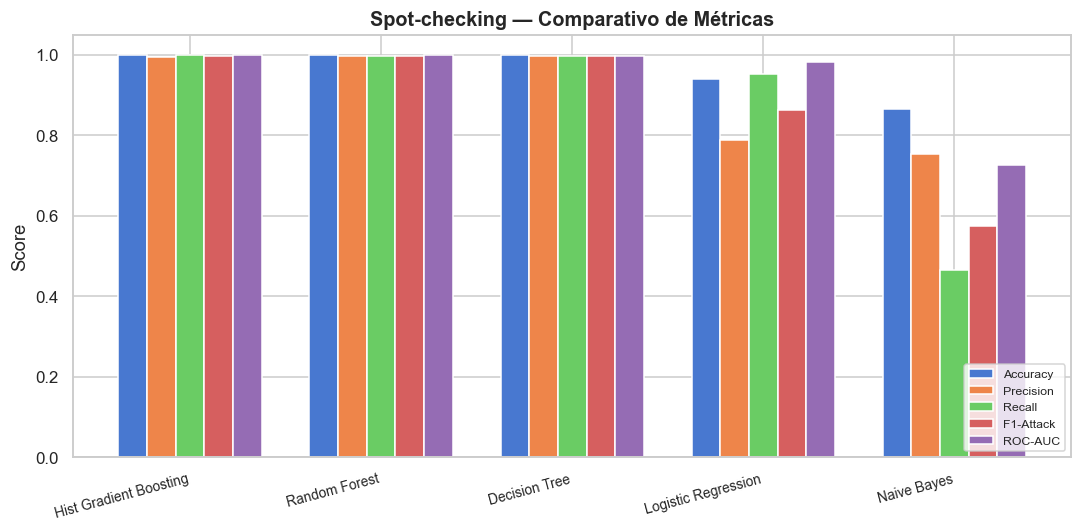

In [104]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

resultados = {
    "Logistic Regression":    (y_pred,     y_prob,     tempo_treino),
    "Random Forest":          (y_pred_rf,  y_prob_rf,  tempo_treino_rf),
    "Decision Tree":          (y_pred_dt,  y_prob_dt,  tempo_treino_dt),
    "Hist Gradient Boosting": (y_pred_hgb, y_prob_hgb, tempo_treino_hgb),
    "Naive Bayes":            (y_pred_nb,  y_prob_nb,  tempo_treino_nb),
}

rows = []
for nome, (ypred, yprob, t) in resultados.items():
    rows.append({
        "Modelo":     nome,
        "Accuracy":   accuracy_score(y_test, ypred),
        "Precision":  precision_score(y_test, ypred, pos_label="Attack"),
        "Recall":     recall_score(y_test, ypred, pos_label="Attack"),
        "F1-Attack":  f1_score(y_test, ypred, pos_label="Attack"),
        "ROC-AUC":    roc_auc_score(y_test, yprob),
        "Tempo (s)":  round(t, 1),
    })

df_resultados = (pd.DataFrame(rows)
                   .sort_values("F1-Attack", ascending=False)
                   .reset_index(drop=True))

print("=== SPOT-CHECKING — Comparativo Final ===\n")
print(df_resultados.to_string(index=False, float_format="%.4f"))

# --- Gráfico comparativo ---
fig, ax = plt.subplots(figsize=(10, 5))
metricas = ["Accuracy", "Precision", "Recall", "F1-Attack", "ROC-AUC"]
x = np.arange(len(df_resultados))
width = 0.15

for i, m in enumerate(metricas):
    ax.bar(x + i * width, df_resultados[m], width, label=m)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_resultados["Modelo"], rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Spot-checking — Comparativo de Métricas", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## AUC ROC

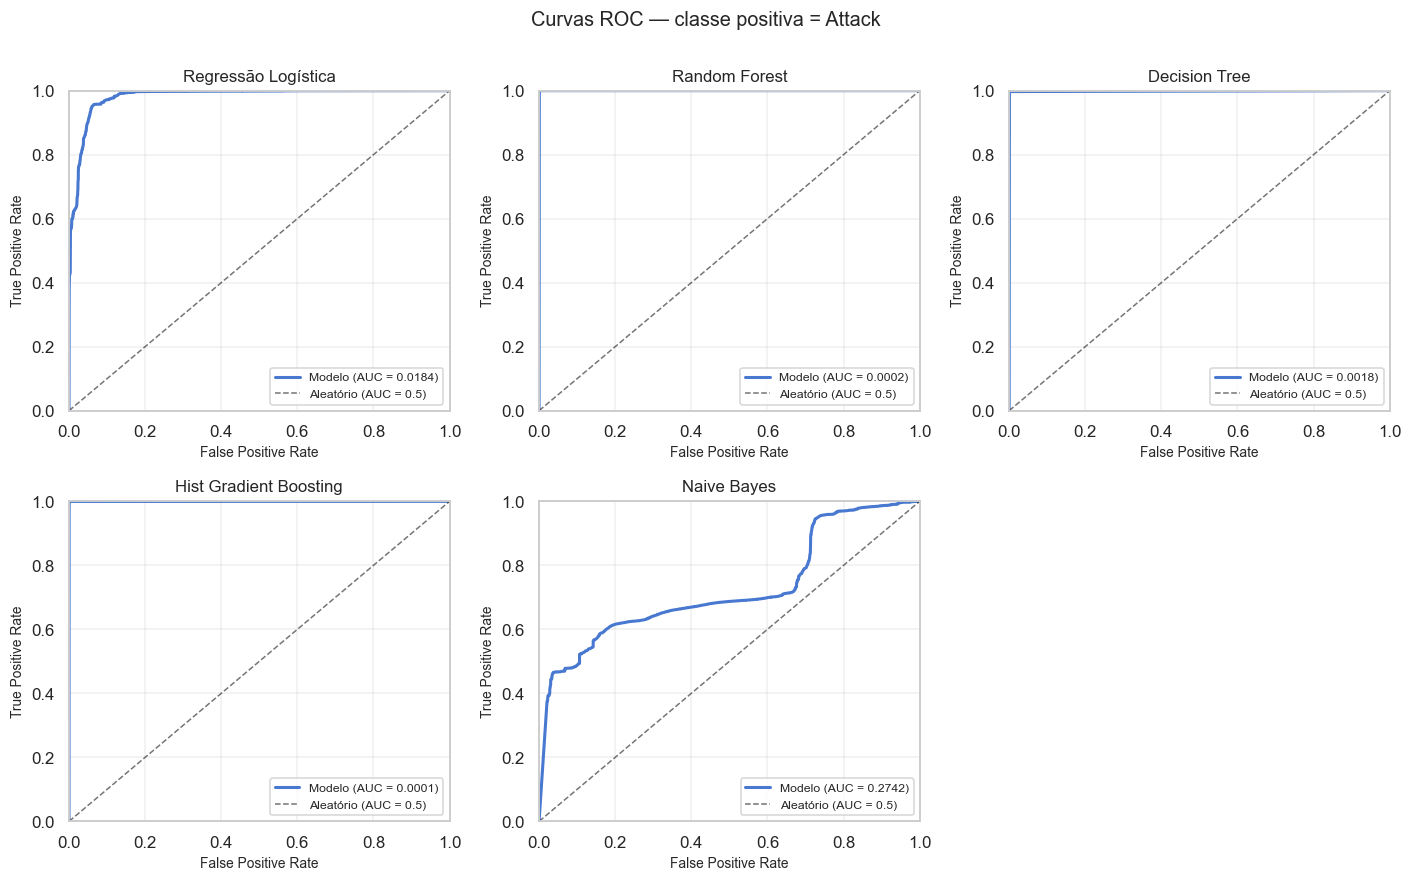


=== Ranking ROC-AUC ===
                        ROC-AUC
Naive Bayes              0.2742
Regressão Logística      0.0184
Decision Tree            0.0018
Random Forest            0.0002
Hist Gradient Boosting   0.0001


In [105]:
from sklearn.metrics import roc_curve

# y_test contém strings ("Attack"/"Benign"), então passamos pos_label explícito.
# Pegamos o índice da classe positiva em classes_ porque a ordem em
# predict_proba pode não ser [Benign, Attack] em todos os modelos.
POS_LABEL = "Attack"

modelos = [
    ("Regressão Logística",    lr,  X_test_sc),
    ("Random Forest",          rf,  X_test),
    ("Decision Tree",          dt,  X_test),
    ("Hist Gradient Boosting", hgb, X_test),
    ("Naive Bayes",            nb,  X_test),
]

resultados_auc = {}

# Grade 2x3 — 5 modelos + 1 célula vazia (escondida no final)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

for ax, (nome, modelo, X_eval) in zip(axes_flat, modelos):
    pos_idx = list(modelo.classes_).index(POS_LABEL)
    y_prob_m = modelo.predict_proba(X_eval)[:, pos_idx]

    auc = roc_auc_score(y_test, y_prob_m, labels=modelo.classes_)
    fpr, tpr, _ = roc_curve(y_test, y_prob_m, pos_label=POS_LABEL)
    resultados_auc[nome] = auc

    ax.plot(fpr, tpr, lw=2, color="C0", label=f"Modelo (AUC = {auc:.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="Aleatório (AUC = 0.5)")
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

# Esconder o 6º subplot vazio
axes_flat[-1].axis("off")

fig.suptitle(f"Curvas ROC — classe positiva = {POS_LABEL}", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

# --- Ranking ROC-AUC ---
df_auc = (pd.Series(resultados_auc, name="ROC-AUC")
            .sort_values(ascending=False)
            .to_frame())
print("\n=== Ranking ROC-AUC ===")
print(df_auc.to_string())

# Validação Cruzada Rigorosa — Repeated Stratified K-Fold

O holdout simples nos deu um único snapshot do desempenho. Aqui aplicamos **Repeated Stratified K-Fold** para obter uma estimativa muito mais robusta: cada modelo é avaliado em 30 divisões diferentes (10 folds × 3 repetições com seeds distintas), reportando média e desvio padrão das métricas.

Esta etapa atende ao requisito do enunciado de **múltiplas repetições com mesmas divisões para todos os algoritmos**.

## 1. Esquema de validação compartilhado

Definimos `cv_global` uma única vez e reutilizamos para todos os modelos — garantindo que cada modelo veja exatamente as mesmas divisões treino/validação em cada uma das 30 iterações.

In [106]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import time

# 10 folds × 3 repetições = 30 avaliações por modelo, todas estratificadas
cv_global = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

print(f"CV: {cv_global.get_n_splits()} avaliações por modelo "
      f"(10 folds × 3 repetições, estratificado, seed=42)")

CV: 30 avaliações por modelo (10 folds × 3 repetições, estratificado, seed=42)


## 2. Dicionário de modelos

Mesma família de algoritmos do spot-checking. A diferença: a Regressão Logística é envolvida num `Pipeline` com `StandardScaler` para que o escalonamento seja ajustado **dentro de cada fold** — caso contrário haveria leakage do test fold no scaler.

In [107]:
modelos_cv = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(class_weight="balanced",
                                      max_iter=1000,
                                      random_state=42,
                                      n_jobs=-1)),
    ]),
    "Random Forest":          RandomForestClassifier(n_estimators=100,
                                                     class_weight="balanced",
                                                     random_state=42,
                                                     n_jobs=-1),
    "Decision Tree":          DecisionTreeClassifier(class_weight="balanced",
                                                     random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                                             random_state=42),
    "Naive Bayes":            GaussianNB(),
}

print(f"{len(modelos_cv)} modelos prontos para avaliação por CV.")

5 modelos prontos para avaliação por CV.


## 3. Função `avaliar_modelos_cv`

Recebe um dicionário `{nome: modelo}` e os dados `(X, y)`, roda `cross_validate` com o `cv_global`, e devolve um DataFrame consolidado com **média e desvio padrão** de F1, Precision, Recall e ROC-AUC.

**Detalhe importante:** convertemos `y` para binário 0/1 internamente (1 = `Attack`). Assim os scorers padrão do sklearn (`'f1'`, `'precision'`, `'recall'`, `'roc_auc'`) funcionam direto, sem precisar configurar `pos_label` em cada um.

In [108]:
def avaliar_modelos_cv(modelos, X, y, cv=cv_global, pos_label="Attack", n_jobs=-1):
    """
    Avalia cada modelo de `modelos` em (X, y) usando o esquema de CV `cv`.

    Retorna:
      df_summary : DataFrame com média ± desvio padrão por métrica.
      raw_scores : dict {nome: {metric: array_de_30_scores}} — útil para
                   testes estatísticos (Friedman, Wilcoxon, etc.).
    """
    y_bin = (y == pos_label).astype(int)
    scoring = ["f1", "precision", "recall", "roc_auc"]

    summary_rows = []
    raw_scores   = {}

    for nome, modelo in modelos.items():
        print(f"  → {nome:25s} ", end="", flush=True)
        t0 = time.time()
        res = cross_validate(
            modelo, X, y_bin,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            return_train_score=False,
        )
        elapsed = time.time() - t0
        print(f"({elapsed/60:.1f} min)")

        raw_scores[nome] = {m: res[f"test_{m}"] for m in scoring}
        summary_rows.append({
            "Modelo": nome,
            "F1 (média)":        res["test_f1"].mean(),
            "F1 (std)":          res["test_f1"].std(),
            "Precision (média)": res["test_precision"].mean(),
            "Precision (std)":   res["test_precision"].std(),
            "Recall (média)":    res["test_recall"].mean(),
            "Recall (std)":      res["test_recall"].std(),
            "ROC-AUC (média)":   res["test_roc_auc"].mean(),
            "ROC-AUC (std)":     res["test_roc_auc"].std(),
        })

    df_summary = pd.DataFrame(summary_rows).set_index("Modelo")
    return df_summary, raw_scores

## 4. Execução e resultados

⚠️ **Custo computacional:** 30 folds × 5 modelos em ~2M linhas — pode levar **algumas horas**. Os progressos por modelo são impressos para acompanhamento.

In [109]:
# --- Cache do CV: scores de 30 folds × 5 modelos × 4 métricas (~5 KB) ---
SCORES_CV_PATH = ARTIFACTS_DIR / "scores_cv.npz"
DF_CV_PATH     = ARTIFACTS_DIR / "df_cv_summary.csv"

if not RECOMPUTE and SCORES_CV_PATH.exists() and DF_CV_PATH.exists():
    data = np.load(SCORES_CV_PATH, allow_pickle=False)
    scores_cv = {}
    for key in data.files:
        nome, metrica = key.split("__", 1)
        scores_cv.setdefault(nome, {})[metrica] = data[key]
    df_cv = pd.read_csv(DF_CV_PATH, index_col=0)
    print(f"✓ CV scores carregados do cache ({sum(len(d) for d in scores_cv.values())} arrays)")
else:
    print("⏳ Executando Repeated Stratified K-Fold (10 folds × 3 repetições × 5 modelos = 150 fits)")
    print("   Tempo estimado: ~6 horas. Os resultados serão salvos em cache para próximas execuções.\n")
    t0 = time.time()
    df_cv, scores_cv = avaliar_modelos_cv(modelos_cv, X_train, y_train)
    print(f"\nTempo total: {(time.time() - t0)/60:.1f} min")
    # Salva: achata o dict {modelo: {metrica: array}} em {modelo__metrica: array}
    flat = {f"{nome}__{m}": arr for nome, d in scores_cv.items() for m, arr in d.items()}
    np.savez_compressed(SCORES_CV_PATH, **flat)
    df_cv.to_csv(DF_CV_PATH)
    print(f"💾 CV scores salvos em {SCORES_CV_PATH.name} e {DF_CV_PATH.name}")

df_cv.round(4)


  → Regressão Logística       (10.4 min)
  → Random Forest             (340.2 min)
  → Decision Tree             (2.7 min)
  → Hist Gradient Boosting    (52.2 min)
  → Naive Bayes               (1.3 min)

Tempo total: 406.8 min


,F1 (média),F1 (std),Precision (média),Precision (std),Recall (média),Recall (std),ROC-AUC (média),ROC-AUC (std)
Modelo,,,,,,,,
Regressão Logística,0.8640,0.0012,0.7905,0.0019,0.9527,0.0011,0.9818,0.0003
Random Forest,0.9973,0.0001,0.9972,0.0002,0.9974,0.0002,0.9998,0.0000
Decision Tree,0.9971,0.0001,0.9967,0.0003,0.9975,0.0003,0.9984,0.0001
Hist Gradient Boosting,0.9969,0.0004,0.9942,0.0008,0.9996,0.0001,0.9999,0.0000
Naive Bayes,0.5753,0.0024,0.7531,0.0029,0.4654,0.0022,0.7265,0.0013


# Teste Estatístico para Comparação de Modelos

Com 30 scores por modelo (10 folds × 3 repetições), aplicamos:

1. **Teste de Friedman** (omnibus) — verifica se há diferença significativa entre os 5 modelos.
2. **Wilcoxon pareado** com correção de Bonferroni — se Friedman for significativo, identifica quais pares de modelos diferem.
3. **Boxplot** dos scores por modelo, ordenados por rank médio — visualização da distribuição e estabilidade.

Métrica principal da comparação: **F1 da classe Attack** (mesma usada no `RandomizedSearchCV`).

Comparando 'f1' em matriz (30, 5)  (30 folds × 5 modelos)

=== Friedman (omnibus) ===
  χ² estatística = 107.7600
  p-valor        = 2.1859e-22
  → HÁ diferença significativa entre os modelos (α=0.05)

=== Wilcoxon pareado (Bonferroni: α corrigido = 0.0050, 10 pares) ===
                     A                      B  Δ média(A-B)     stat  p-valor A>B sig?
   Regressão Logística          Random Forest       -0.1333   0.0000   0.0000  ✓ (B>A)
   Regressão Logística          Decision Tree       -0.1331   0.0000   0.0000  ✓ (B>A)
   Regressão Logística Hist Gradient Boosting       -0.1329   0.0000   0.0000  ✓ (B>A)
   Regressão Logística            Naive Bayes        0.2888   0.0000   0.0000        ✓
         Random Forest          Decision Tree        0.0002   0.0000   0.0000        ✓
         Random Forest            Naive Bayes        0.4220   0.0000   0.0000        ✓
         Decision Tree            Naive Bayes        0.4218   0.0000   0.0000        ✓
Hist Gradient Boosting          

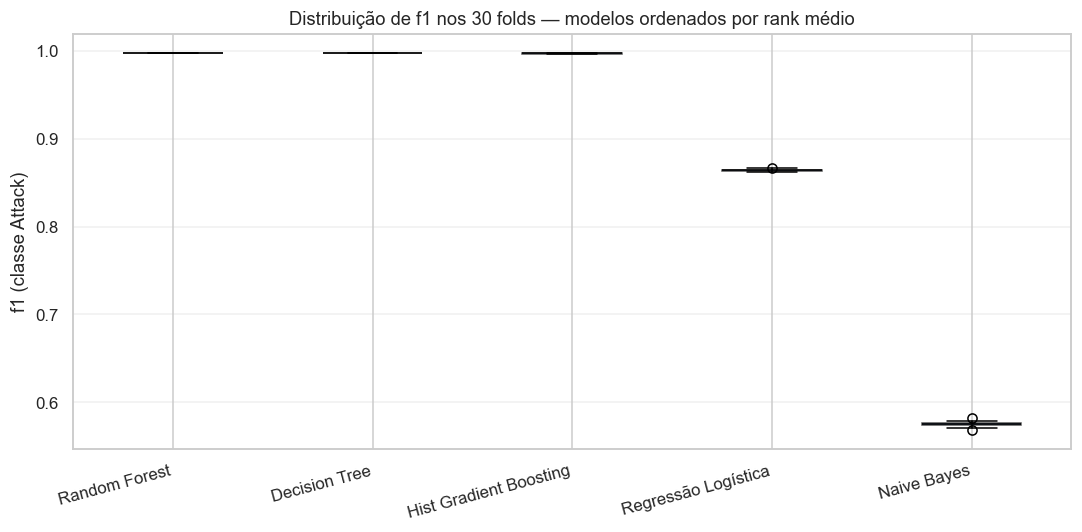

In [110]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import numpy as np

# ─── Métrica principal de comparação: F1 da classe Attack ────────────────
metrica = "f1"

nomes  = list(scores_cv.keys())
matriz = np.column_stack([scores_cv[n][metrica] for n in nomes])  # (30 folds, 5 modelos)
print(f"Comparando '{metrica}' em matriz {matriz.shape}  "
      f"({matriz.shape[0]} folds × {matriz.shape[1]} modelos)\n")

# ─── 1) Friedman: existe diferença entre os modelos? ────────────────────
stat_f, p_friedman = friedmanchisquare(*matriz.T)
alpha = 0.05
print("=== Friedman (omnibus) ===")
print(f"  χ² estatística = {stat_f:.4f}")
print(f"  p-valor        = {p_friedman:.4e}")
sig_friedman = p_friedman < alpha
print(f"  → {'HÁ' if sig_friedman else 'NÃO há'} diferença significativa "
      f"entre os modelos (α={alpha})\n")

# ─── 2) Wilcoxon pareado com correção de Bonferroni ─────────────────────
pares      = list(combinations(range(len(nomes)), 2))
alpha_bonf = alpha / len(pares)
print(f"=== Wilcoxon pareado (Bonferroni: α corrigido = {alpha_bonf:.4f}, "
      f"{len(pares)} pares) ===")

linhas = []
for i, j in pares:
    stat_w, p = wilcoxon(matriz[:, i], matriz[:, j])
    linhas.append({
        "A":           nomes[i],
        "B":           nomes[j],
        "Δ média(A-B)": matriz[:, i].mean() - matriz[:, j].mean(),
        "stat":        stat_w,
        "p-valor":     p,
        "A>B sig?":    "✓" if (p < alpha_bonf and matriz[:, i].mean() > matriz[:, j].mean())
                       else ("✓ (B>A)" if p < alpha_bonf else "—"),
    })

df_wilcoxon = pd.DataFrame(linhas).sort_values("p-valor")
print(df_wilcoxon.to_string(index=False))
print()

# ─── 3) Boxplot ordenado por rank médio (melhor à esquerda) ─────────────
df_scores = pd.DataFrame(matriz, columns=nomes)
rank_medio = df_scores.rank(axis=1, ascending=False).mean()
ordem      = rank_medio.sort_values().index.tolist()

print("=== Rank médio (1 = melhor) ===")
print(rank_medio.sort_values().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([df_scores[c] for c in ordem], labels=ordem, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0"); patch.set_alpha(0.65)
for median in bp["medians"]:
    median.set_color("black")
ax.set_ylabel(f"{metrica} (classe Attack)")
ax.set_title(f"Distribuição de {metrica} nos 30 folds — modelos ordenados por rank médio")
ax.set_xticklabels(ordem, rotation=15, ha="right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Otimização de Hiperparâmetros

O spot-checking mostrou quais algoritmos têm maior potencial. Agora aplicamos **RandomizedSearchCV** nos dois melhores — Random Forest e Hist Gradient Boosting — para encontrar a configuração ideal de hiperparâmetros.

**Estratégia:**
- Amostra estratificada de 20% do treino para o CV (viabilidade computacional)
- `StratifiedKFold(5)` — 5 folds mantendo a proporção de classes em cada fold
- `RandomizedSearchCV` com `n_iter=20` combinações sorteadas
- Modelo final retreinado nos dados completos de treino com os melhores hiperparâmetros
- Avaliação final no test set original (nunca visto)

## Passo 1 — Amostra Estratificada para o CV

Usar 2.3M linhas em 5 folds × 20 iterações seria muito lento. Usamos 20% do treino (~460k linhas), mantendo a proporção de classes via amostragem estratificada. O modelo final será retreinado nos dados completos.

In [111]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# Amostra estratificada de 20% do treino para o CV
X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train,
    train_size=0.20,
    random_state=42,
    stratify=y_train
)

print(f"Tamanho da amostra CV: {X_cv.shape[0]:,} linhas ({X_cv.shape[0]/X_train.shape[0]*100:.1f}% do treino)")
print(f"\nDistribuição das classes na amostra:")
print(y_cv.value_counts(normalize=True).mul(100).round(2))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Tamanho da amostra CV: 451,992 linhas (20.0% do treino)

Distribuição das classes na amostra:
Attack
Benign   80.3100
Attack   19.6900
Name: proportion, dtype: float64


## Passo 2 — Random Forest — Busca de Hiperparâmetros

Parâmetros testados:
- `n_estimators`: quantidade de árvores na floresta
- `max_depth`: profundidade máxima de cada árvore (controla overfitting)
- `min_samples_leaf`: mínimo de amostras em cada folha (controla overfitting)
- `max_features`: quantidade de features consideradas em cada split

20 combinações sorteadas × 5 folds = 100 treinos no total.

In [112]:
BEST_RF_PATH = ARTIFACTS_DIR / "best_params_rf.json"

if not RECOMPUTE and BEST_RF_PATH.exists():
    with open(BEST_RF_PATH) as f:
        info_rf = json.load(f)
    best_params_rf = info_rf["best_params"]
    best_score_rf = info_rf["best_score"]
    tempo_search_rf = info_rf.get("tempo_min", 0) * 60
    print(f"✓ Best params RF carregados (F1 CV: {best_score_rf:.4f})")
    print(f"   {best_params_rf}")
else:
    params_rf = {
        "n_estimators":    [100, 200, 300, 500],
        "max_depth":       [10, 20, 30, None],
        "min_samples_leaf":[1, 2, 5, 10],
        "max_features":    ["sqrt", "log2", 0.3],
    }

    search_rf = RandomizedSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        param_distributions=params_rf,
        n_iter=20,
        scoring="f1",
        cv=cv,
        refit=True,
        verbose=1,
        random_state=42,
        n_jobs=-1,
    )

    t0 = time.time()
    search_rf.fit(X_cv, y_cv)
    tempo_search_rf = time.time() - t0
    best_params_rf = search_rf.best_params_
    best_score_rf  = search_rf.best_score_

    with open(BEST_RF_PATH, "w") as f:
        json.dump({
            "best_params": best_params_rf,
            "best_score": float(best_score_rf),
            "tempo_min": tempo_search_rf / 60,
        }, f, indent=2)

    print(f"\nBusca concluída em {tempo_search_rf/60:.1f} min")
    print(f"Melhores hiperparâmetros:\n{best_params_rf}")
    print(f"Melhor F1 no CV: {best_score_rf:.4f}")
    print(f"💾 Salvo em {BEST_RF_PATH.name}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>.


Busca concluída em 21.6 min
Melhores hiperparâmetros:
{'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': 10}
Melhor F1 no CV: nan


## Passo 3 — Random Forest Otimizado — Avaliação Final

Com os melhores hiperparâmetros encontrados, retreinamos o modelo nos **dados completos de treino** (não só a amostra) e avaliamos no test set.

Tempo de treino (dados completos): 144.0s

=== Classification Report — Random Forest Otimizado ===
              precision    recall  f1-score   support

      Attack       0.98      1.00      0.99    111273
      Benign       1.00      1.00      1.00    453718

    accuracy                           1.00    564991
   macro avg       0.99      1.00      0.99    564991
weighted avg       1.00      1.00      1.00    564991

ROC-AUC: 0.9998


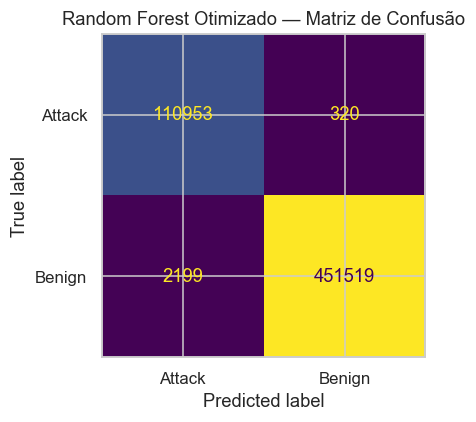

In [113]:
# Retreina com os melhores parâmetros nos dados completos de treino
RF_OPT_PATH = ARTIFACTS_DIR / "rf_optimized.joblib"

if not RECOMPUTE and RF_OPT_PATH.exists():
    rf_opt, tempo_rf_opt = joblib.load(RF_OPT_PATH)
    print(f"✓ RF otimizado carregado do cache (tempo original: {tempo_rf_opt:.1f}s)")
else:
    rf_opt = RandomForestClassifier(
        **best_params_rf,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    t0 = time.time()
    rf_opt.fit(X_train, y_train)
    tempo_rf_opt = time.time() - t0
    joblib.dump((rf_opt, tempo_rf_opt), RF_OPT_PATH, compress=3)
    print(f"Tempo de treino (dados completos): {tempo_rf_opt:.1f}s")
    print(f"💾 RF otimizado salvo em {RF_OPT_PATH.name}")

y_pred_rf_opt = rf_opt.predict(X_test)
y_prob_rf_opt = rf_opt.predict_proba(X_test)[:, 1]

print("\n=== Classification Report — Random Forest Otimizado ===")
print(classification_report(y_test, y_pred_rf_opt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf_opt):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_opt, ax=ax, colorbar=False)
ax.set_title("Random Forest Otimizado — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Passo 4 — Hist Gradient Boosting — Busca de Hiperparâmetros

Parâmetros testados:
- `max_iter`: número de árvores (equivalente ao `n_estimators` do RF)
- `learning_rate`: tamanho do passo de cada árvore — valores menores + mais árvores = mais preciso
- `max_depth`: profundidade máxima de cada árvore
- `min_samples_leaf`: mínimo de amostras em cada folha
- `l2_regularization`: penalidade L2 para controlar overfitting

In [114]:
BEST_HGB_PATH = ARTIFACTS_DIR / "best_params_hgb.json"

if not RECOMPUTE and BEST_HGB_PATH.exists():
    with open(BEST_HGB_PATH) as f:
        info_hgb = json.load(f)
    best_params_hgb = info_hgb["best_params"]
    best_score_hgb = info_hgb["best_score"]
    tempo_search_hgb = info_hgb.get("tempo_min", 0) * 60
    print(f"✓ Best params HGB carregados (F1 CV: {best_score_hgb:.4f})")
    print(f"   {best_params_hgb}")
else:
    params_hgb = {
        "max_iter":          [100, 200, 300, 500],
        "learning_rate":     [0.01, 0.05, 0.1, 0.2],
        "max_depth":         [3, 5, 7, None],
        "min_samples_leaf":  [20, 50, 100, 200],
        "l2_regularization": [0.0, 0.1, 0.5, 1.0],
    }

    search_hgb = RandomizedSearchCV(
        HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
        param_distributions=params_hgb,
        n_iter=20,
        scoring="f1",
        cv=cv,
        refit=True,
        verbose=1,
        random_state=42,
        n_jobs=-1,
    )

    t0 = time.time()
    search_hgb.fit(X_cv, y_cv)
    tempo_search_hgb = time.time() - t0
    best_params_hgb = search_hgb.best_params_
    best_score_hgb  = search_hgb.best_score_

    with open(BEST_HGB_PATH, "w") as f:
        json.dump({
            "best_params": best_params_hgb,
            "best_score": float(best_score_hgb),
            "tempo_min": tempo_search_hgb / 60,
        }, f, indent=2)

    print(f"\nBusca concluída em {tempo_search_hgb/60:.1f} min")
    print(f"Melhores hiperparâmetros:\n{best_params_hgb}")
    print(f"Melhor F1 no CV: {best_score_hgb:.4f}")
    print(f"💾 Salvo em {BEST_HGB_PATH.name}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Busca concluída em 3.7 min
Melhores hiperparâmetros:
{'min_samples_leaf': 50, 'max_iter': 500, 'max_depth': 3, 'learning_rate': 0.01, 'l2_regularization': 0.5}
Melhor F1 no CV: nan


## Passo 5 — Hist Gradient Boosting Otimizado — Avaliação Final

Mesma lógica do RF: retreina nos dados completos com os melhores parâmetros e avalia no test set.

Tempo de treino (dados completos): 31.0s

=== Classification Report — HGB Otimizado ===
              precision    recall  f1-score   support

      Attack       0.93      0.99      0.96    111273
      Benign       1.00      0.98      0.99    453718

    accuracy                           0.98    564991
   macro avg       0.96      0.99      0.97    564991
weighted avg       0.98      0.98      0.98    564991

ROC-AUC: 0.9984


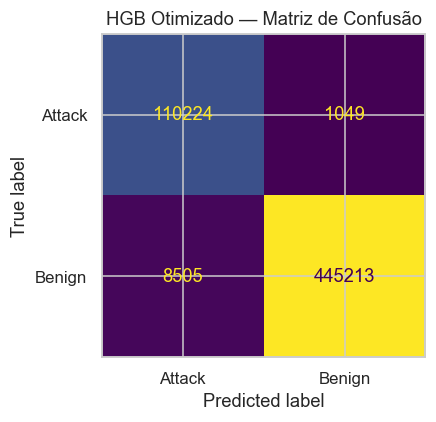

In [115]:
HGB_OPT_PATH = ARTIFACTS_DIR / "hgb_optimized.joblib"

if not RECOMPUTE and HGB_OPT_PATH.exists():
    hgb_opt, tempo_hgb_opt = joblib.load(HGB_OPT_PATH)
    print(f"✓ HGB otimizado carregado do cache (tempo original: {tempo_hgb_opt:.1f}s)")
else:
    hgb_opt = HistGradientBoostingClassifier(
        **best_params_hgb,
        class_weight="balanced",
        random_state=42
    )
    t0 = time.time()
    hgb_opt.fit(X_train, y_train)
    tempo_hgb_opt = time.time() - t0
    joblib.dump((hgb_opt, tempo_hgb_opt), HGB_OPT_PATH, compress=3)
    print(f"Tempo de treino (dados completos): {tempo_hgb_opt:.1f}s")
    print(f"💾 HGB otimizado salvo em {HGB_OPT_PATH.name}")

y_pred_hgb_opt = hgb_opt.predict(X_test)
y_prob_hgb_opt = hgb_opt.predict_proba(X_test)[:, 1]

print("\n=== Classification Report — HGB Otimizado ===")
print(classification_report(y_test, y_pred_hgb_opt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_hgb_opt):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_hgb_opt, ax=ax, colorbar=False)
ax.set_title("HGB Otimizado — Matriz de Confusão")
plt.tight_layout()
plt.show()


## Passo 6 — Comparativo Final: Baseline vs Otimizado

Comparação entre os modelos com hiperparâmetros padrão (spot-checking) e os mesmos modelos após otimização.

=== Baseline vs Otimizado ===

       Modelo  Precision  Recall  F1-Attack  ROC-AUC
  RF Baseline     0.9973  0.9972     0.9972   0.9998
 RF Otimizado     0.9806  0.9971     0.9888   0.9998
 HGB Baseline     0.9955  0.9996     0.9975   0.9999
HGB Otimizado     0.9284  0.9906     0.9585   0.9984


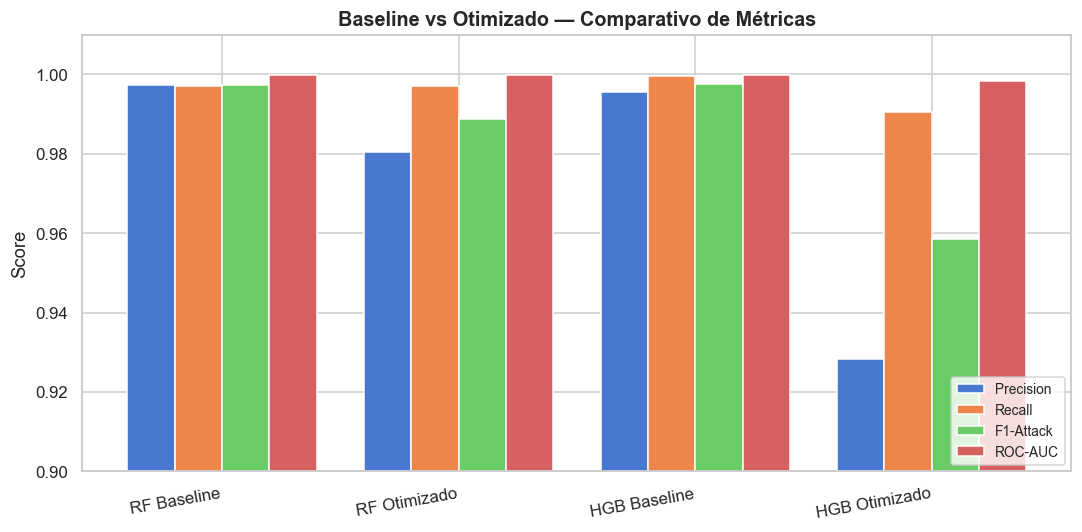

In [116]:
comparativo = [
    ("RF Baseline",      y_pred_rf,      y_prob_rf),
    ("RF Otimizado",     y_pred_rf_opt,  y_prob_rf_opt),
    ("HGB Baseline",     y_pred_hgb,     y_prob_hgb),
    ("HGB Otimizado",    y_pred_hgb_opt, y_prob_hgb_opt),
]

rows_cmp = []
for nome, ypred, yprob in comparativo:
    rows_cmp.append({
        "Modelo":    nome,
        "Precision": precision_score(y_test, ypred, pos_label="Attack"),
        "Recall":    recall_score(y_test, ypred, pos_label="Attack"),
        "F1-Attack": f1_score(y_test, ypred, pos_label="Attack"),
        "ROC-AUC":   roc_auc_score(y_test, yprob),
    })

df_cmp = pd.DataFrame(rows_cmp)
print("=== Baseline vs Otimizado ===\n")
print(df_cmp.to_string(index=False, float_format="%.4f"))

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(10, 5))
metricas_cmp = ["Precision", "Recall", "F1-Attack", "ROC-AUC"]
x_cmp = np.arange(len(df_cmp))
w = 0.2

for i, m in enumerate(metricas_cmp):
    ax.bar(x_cmp + i * w, df_cmp[m], w, label=m)

ax.set_xticks(x_cmp + w * 1.5)
ax.set_xticklabels(df_cmp["Modelo"], rotation=10, ha="right")
ax.set_ylim(0.9, 1.01)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Otimizado — Comparativo de Métricas", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# Interpretabilidade do Modelo

O enunciado exige explorar o impacto dos atributos na tomada de decisão do melhor modelo. Usamos duas abordagens complementares:

1. **Feature Importance nativa do Random Forest** — mede quanto cada feature reduziu a impureza (Gini) em média ao longo de todas as árvores. Rápida e direta.
2. **SHAP (SHapley Additive exPlanations)** — explica a predição de cada instância individualmente, mostrando quanto cada feature contribuiu para classificar como Attack ou Benign. Mais robusto e interpretável que o Gini importance.

## Feature Importance Nativa — Random Forest (Gini Impurity)

A importância de Gini mede quanto cada feature reduz a impureza média ao longo de todas as árvores e splits. É uma estimativa rápida e eficiente, mas pode superestimar features com alta cardinalidade ou contínuas.


Top 20 features por importância (Gini):
                Feature  Importance
       Destination Port     0.10415
    Average Packet Size     0.10064
  Bwd Packet Length Min     0.10059
Init_Win_bytes_backward     0.09418
  Bwd Packet Length Std     0.06066
 Init_Win_bytes_forward     0.05884
  Fwd Packet Length Min     0.05131
      Packet Length Std     0.04955
 Packet Length Variance     0.04733
      Min Packet Length     0.04643
   Avg Fwd Segment Size     0.03602
      Subflow Fwd Bytes     0.03136
   Avg Bwd Segment Size     0.03058
      Subflow Bwd Bytes     0.02237
  Fwd Packet Length Std     0.01731
    Subflow Fwd Packets     0.01445
            Fwd IAT Min     0.01430
           Flow Bytes/s     0.01320
         URG Flag Count     0.01266
          Fwd IAT Total     0.00947


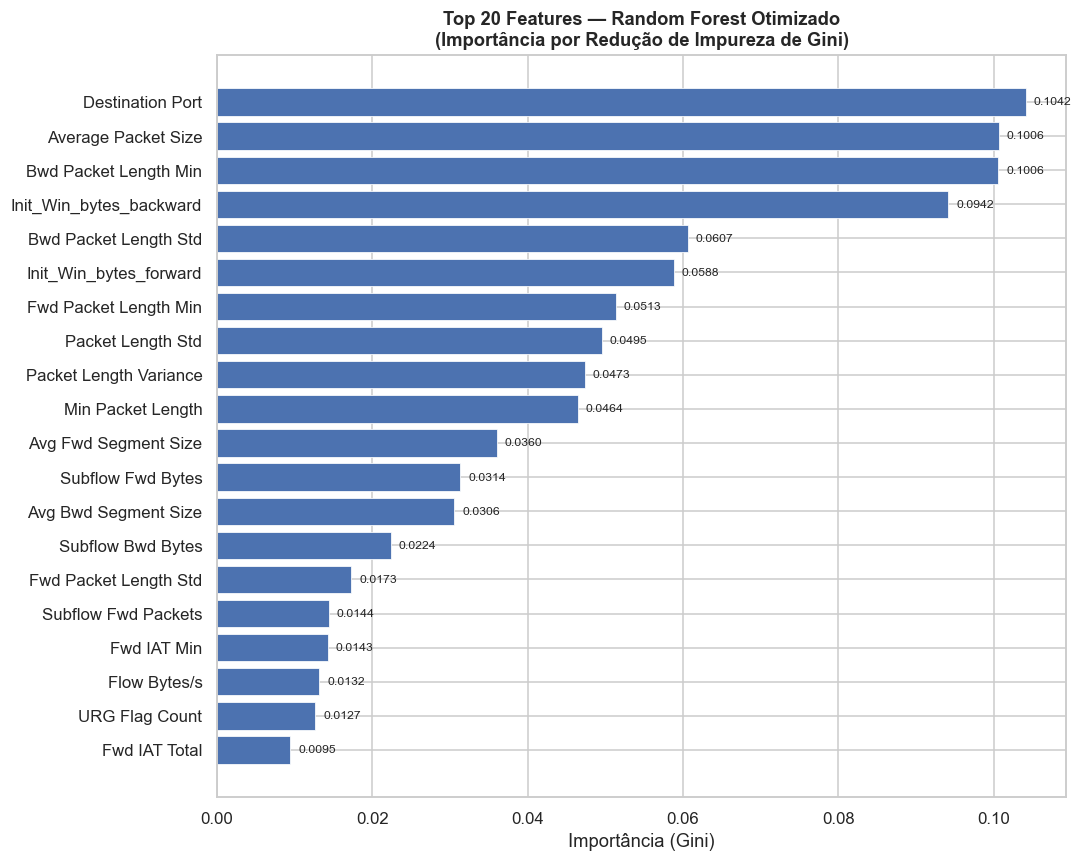

In [117]:
# Usa o melhor modelo disponível: RF Otimizado
# (caso a otimização não tenha melhorado, rf_opt e rf têm desempenho equivalente)
importances = rf_opt.feature_importances_
feat_imp = (pd.DataFrame({"Feature": feature_cols, "Importance": importances})
              .sort_values("Importance", ascending=False)
              .reset_index(drop=True))

print("Top 20 features por importância (Gini):")
print(feat_imp.head(20).to_string(index=False, float_format="%.5f"))

# --- Gráfico horizontal ---
top20 = feat_imp.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20["Feature"][::-1], top20["Importance"][::-1],
               color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importância (Gini)")
ax.set_title("Top 20 Features — Random Forest Otimizado\n(Importância por Redução de Impureza de Gini)",
             fontsize=12, fontweight="bold")

for bar, val in zip(bars, top20["Importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../archive/interp_01_feature_importance_gini.png", dpi=150, bbox_inches="tight")
plt.show()


## SHAP — SHapley Additive exPlanations

SHAP atribui a cada feature uma contribuição marginal para a predição de **cada instância** individual, baseado na teoria dos jogos cooperativos. É mais robusto que a importância de Gini pois:
- Detecta tanto efeitos positivos quanto negativos de cada feature
- Considera interações entre features
- É consistente: se uma feature passa a ser mais importante, seu valor SHAP aumenta

Usamos `TreeExplainer`, otimizado para modelos baseados em árvores (Random Forest), que computa os valores SHAP exatamente (sem aproximação).

**Amostra de 5.000 instâncias** do test set para o cálculo (suficiente para os padrões globais, viável computacionalmente).


In [118]:
import shap

# Amostra estratificada de 5.000 instâncias do test set (determinística com seed=42)
shap_sample = X_test.sample(n=5000, random_state=42)

SHAP_VALUES_PATH = ARTIFACTS_DIR / "shap_values.npz"

if not RECOMPUTE and SHAP_VALUES_PATH.exists():
    shap_values = np.load(SHAP_VALUES_PATH)["values"]
    print(f"✓ Valores SHAP carregados do cache  shape={shap_values.shape}")
else:
    explainer = shap.TreeExplainer(rf_opt)
    print("⏳ Computando valores SHAP para 5.000 instâncias...")
    shap_values_raw = explainer.shap_values(shap_sample)

    # Compatibilidade entre versões do shap:
    # - shap < 0.44: retorna lista [array_classe0, array_classe1]
    # - shap >= 0.44: retorna ndarray 3D (n_samples, n_features, n_classes)
    classes = list(rf_opt.classes_)
    attack_idx = classes.index("Attack")

    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[attack_idx]
    elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values = shap_values_raw[:, :, attack_idx]
    else:
        shap_values = shap_values_raw

    np.savez_compressed(SHAP_VALUES_PATH, values=shap_values)
    print(f"💾 SHAP values salvos em {SHAP_VALUES_PATH.name}")
    print(f"Classes: {classes} — usando índice {attack_idx} ('Attack')")

print(f"\nShape dos valores SHAP: {shap_values.shape}")
print(f"\nTop 10 features por |SHAP| médio:")
mean_abs_shap = pd.DataFrame({
    "Feature": feature_cols,
    "mean_|SHAP|": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_|SHAP|", ascending=False).head(10)
print(mean_abs_shap.to_string(index=False, float_format="%.5f"))


Computando valores SHAP para 5.000 instâncias do test set...
Classes: ['Attack', 'Benign'] — usando índice 0 ('Attack')
Shape dos valores SHAP: (5000, 47)

Top 10 features por |SHAP| médio:
                Feature  mean_|SHAP|
       Destination Port      0.08708
    Average Packet Size      0.05082
  Bwd Packet Length Min      0.05051
Init_Win_bytes_backward      0.04950
  Bwd Packet Length Std      0.03707
 Init_Win_bytes_forward      0.03053
      Min Packet Length      0.02829
  Fwd Packet Length Min      0.02646
      Packet Length Std      0.02321
   Avg Bwd Segment Size      0.02161


### SHAP Summary Plot (Beeswarm)

O beeswarm plot mostra:
- **Eixo X**: Valor SHAP — positivo empurra para "Attack", negativo empurra para "Benign"
- **Cor**: Valor da feature (vermelho = alto, azul = baixo)
- **Posição vertical**: Features rankeadas por importância (|SHAP| médio)
- **Cada ponto**: Uma instância da amostra


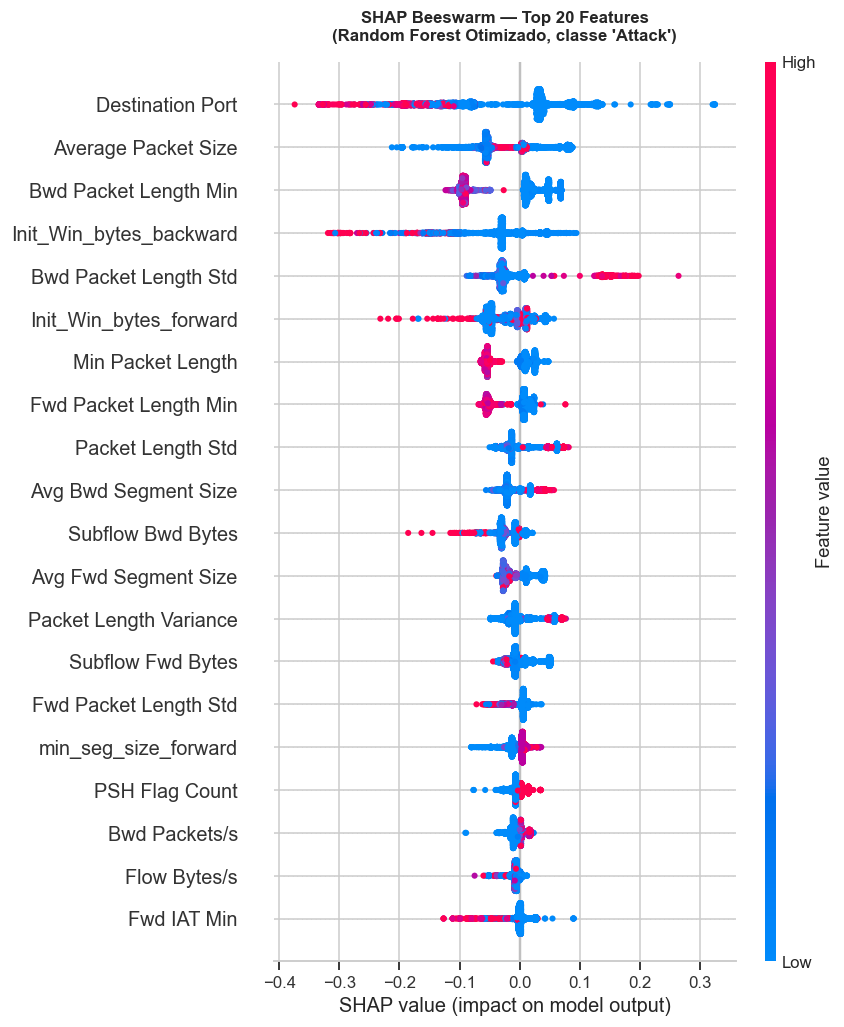

In [119]:
plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_cols,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm — Top 20 Features\n(Random Forest Otimizado, classe 'Attack')",
          fontsize=11, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("../archive/interp_02_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


### SHAP Dependence Plots — Top 5 Features

Os dependence plots mostram como o valor de uma feature específica afeta a predição (eixo Y = valor SHAP), coloridos pela feature que mais interage com ela. Revelam não-linearidades e interações entre features.


Top 5 features para dependence plots: ['Destination Port', 'Average Packet Size', 'Bwd Packet Length Min', 'Init_Win_bytes_backward', 'Bwd Packet Length Std']


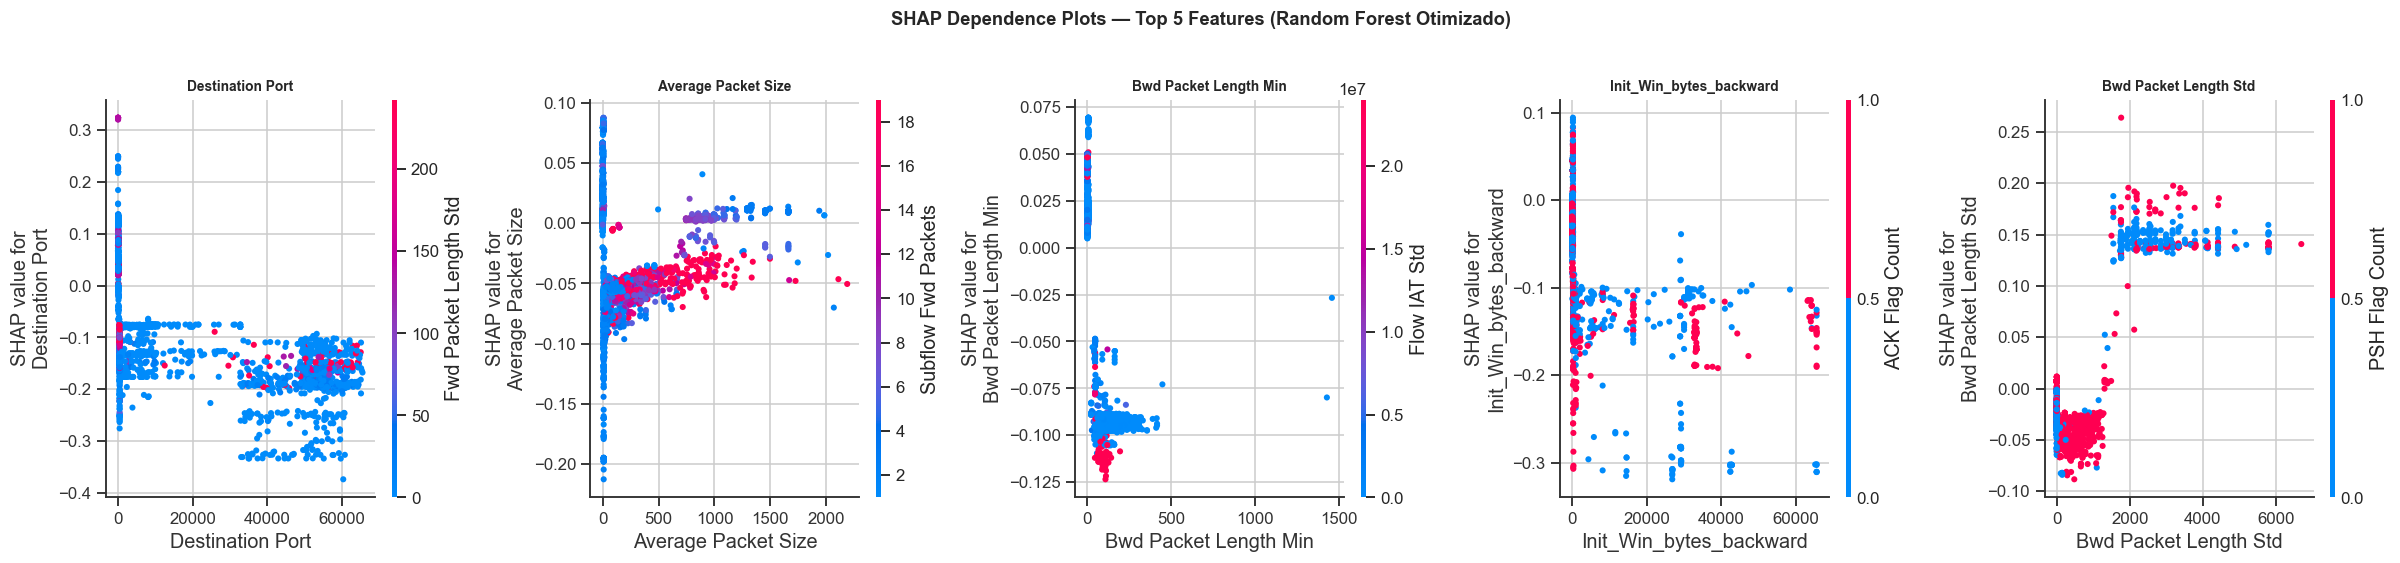

In [120]:
# Top 5 features por |SHAP| médio
top5_features = (pd.DataFrame({
    "Feature": feature_cols,
    "mean_|SHAP|": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_|SHAP|", ascending=False).head(5)["Feature"].tolist())

print("Top 5 features para dependence plots:", top5_features)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, feat in enumerate(top5_features):
    feat_idx = feature_cols.index(feat)
    # shap.dependence_plot retorna um Axes; usamos ax= para embuti-lo na grade
    shap.dependence_plot(
        feat_idx,
        shap_values,
        shap_sample.values,
        feature_names=feature_cols,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(feat, fontsize=9, fontweight="bold")

plt.suptitle("SHAP Dependence Plots — Top 5 Features (Random Forest Otimizado)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../archive/interp_03_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Reprodutibilidade

Versões dos pacotes e ambiente Python utilizados neste notebook.


In [121]:
import sys
import platform
import importlib.metadata
from datetime import datetime

pkgs = ["pandas", "numpy", "scikit-learn", "shap", "matplotlib", "seaborn",
        "scipy", "pyarrow"]

print(f"{'='*55}")
print(f"  Ambiente de Execução — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"{'='*55}")
print(f"  Python    : {sys.version.split()[0]}")
print(f"  Plataforma: {platform.system()} {platform.release()}")
print(f"{'='*55}")
for pkg in pkgs:
    try:
        version = importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        version = "não instalado"
    print(f"  {pkg:<18}: {version}")
print(f"{'='*55}")


  Ambiente de Execução — 2026-05-10 01:20
  Python    : 3.14.4
  Plataforma: Darwin 25.4.0
  pandas            : 3.0.2
  numpy             : 2.4.4
  scikit-learn      : 1.8.0
  shap              : 0.51.0
  matplotlib        : 3.10.9
  seaborn           : 0.13.2
  scipy             : 1.17.1
  pyarrow           : 24.0.0
